In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
import astropy.units as u
from tqdm import tqdm
import glob, os

import sys
sys.path.append("../scripts")
from forward_model import make_wcs

import matplotlib.pylab as pylab
plt.style.use("science")
params = {
         'axes.labelsize': 20,
         'axes.titlesize': 25,
         'ytick.labelsize' :20,
         'xtick.labelsize' :20,
         'xtick.major.size': 8,
         'xtick.minor.size': 4,
         'xtick.major.width': 1,
         'xtick.minor.width': 1,
         'ytick.color': "w",
         'xtick.color': "w",
         'axes.labelcolor': "k",
         'ytick.labelcolor' : "k",
         'xtick.labelcolor' : "k",
         }
pylab.rcParams.update(params)


# Run this after running aligning_smacs_targets_drizzlepac since we update the WCS there

In [2]:
from scipy.interpolate import interpn
from matplotlib.colors import Normalize
import matplotlib.cm as cm


def density_scatter(points, fig=None, ax=None, sort=True, bins=20, cmap="magma", norm=None, ticks=None, colorbar=False, **kwargs):
    """
    Scatter plot colored by 2d histogram
    """
    x = points[:, 0]
    y = points[:, 1]
    if ax is None:
        fig, ax = plt.subplots()
    data, x_edges, y_edges = np.histogram2d(x, y, bins=bins, density=True)
    x_bins = 0.5 * (x_edges[1:] + x_edges[:-1])
    y_bins = 0.5 * (y_edges[1:] + y_edges[:-1])
    z = interpn((x_bins, y_bins), data, np.vstack([x, y]).T, method="splinef2d", bounds_error=False)
    z[np.where(np.isnan(z))] = 0.0
    # Sort the points by density, so that the densest points are plotted last
    if sort:
        idx = z.argsort()
        x, y, z = x[idx], y[idx], z[idx]
    if norm is None:
        norm = Normalize(vmin=z.min(), vmax=z.max())
    ax.scatter(x, y, c=z, cmap=cmap, norm=norm, **kwargs)
    if fig is not None:
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        box = ax.get_position()
        cax = plt.axes([box.x0*1.01 + box.width * 1.05, box.y0, 0.02, box.height])
        fig.colorbar(sm, cax=cax, ticks=ticks)
        cax.set_ylabel('Density')
    return ax


In [3]:
def interpolate(image, x, y, zero_fill=True):
    """
    Interpolation function, without a batch size. To make it batched, used vmap from functorch.
    """
    H, W = image.shape
    x = x.flatten()
    y = y.flatten()
    idxs_out_of_bounds = (y < 0) | (y > W-1) | (x < 0) | (x > W-1)
    x0 = np.floor(x).astype(np.int32)
    x1 = x0 + 1
    y0 = np.floor(y).astype(np.int32)
    y1 = y0 + 1

    x0 = np.clip(x0, 0, W - 1)
    x1 = np.clip(x1, 0, W - 1)
    y0 = np.clip(y0, 0, H - 1)
    y1 = np.clip(y1, 0, H - 1)
    x = np.clip(x, 0, W - 1)
    y = np.clip(y, 0, H - 1)

    Ia = image[x0, y0]
    Ib = image[x0, y1]
    Ic = image[x1, y0]
    Id = image[x1, y1]

    wa = (x1 - x) * (y1 - y)
    wb = (x1 - x) * (y - y0)
    wc = (x - x0) * (y1 - y)
    wd = (x - x0) * (y - y0)

    result = (wa * Ia + wb * Ib + wc * Ic + wd * Id)
    result[idxs_out_of_bounds] = 0

    return result


# Load data

In [4]:
data_dir = "../data/SMACSJ0723/HST/"
flt_paths = glob.glob(data_dir + "*flt.fits")

filters = ["F105W", "F125W", "F160W"]

flt_paths_sorted = {
    "F160W": [p for p in flt_paths if "f160w" in p],
    "F125W": [p for p in flt_paths if "f125w" in p],
    "F105W": [p for p in flt_paths if "f160w" not in p and "f125w" not in p],
    "F105WO1": [p for p in flt_paths if "f160w" not in p and "f125w" not in p and "za" in p], # first orbit (infered from the TIME-OBS and DATE-OBS keywords
    "F105WO2": [p for p in flt_paths if "f160w" not in p and "f125w" not in p and "bm" in p]  # second orbit
}

In [5]:
TARGET = 2
FILTER = "F160W"


coord0 = SkyCoord("7:23:24.5462", "-73:27:20.172", unit=(u.hourangle, u.deg))
coord1 = SkyCoord("7:23:22.0805", "-73:27:24.575", unit=(u.hourangle, u.deg))
coord2 = SkyCoord("7:23:20.7483", "-73:26:07.203", unit=(u.hourangle, u.deg))
# coord3 = SkyCoord("7:23:01.6118", "-73:26:45.888", unit=(u.hourangle, u.deg))

coords = [coord0, coord1, coord2]
coord = coords[TARGET]

# paths = glob.glob(f"../data/smacs*target{TARGET}*{FILTER.upper()}*.fits")
# data = []
# for p in paths:
#     data.append(fits.open(p))
# observations = np.stack([data[i]["SCI"].data.astype(np.float32) for i in range(len(paths))], axis=0)
# wcs_list = [WCS(data[i]["SCI"].header, data[i]) for i in range(len(paths))]
    
# We need to make larger cutouts to have more context to make alignment faithful 
size = 64 if TARGET == 2 else 128 # TARGET = 2 is close to the edge 
cutouts = {i: [] for i in range(3)}
wcs_lists = {i: [] for i in range(3)}
paths = flt_paths_sorted[FILTER]
for i, path in enumerate(paths):
    data = fits.open(path)
    for target in range(3):
        cutout = Cutout2D(data["SCI", 1].data, coords[target], size, wcs=WCS(data["SCI"].header, data))
        wcs = cutout.wcs
        cutouts[target].append(cutout.data)
        wcs_lists[target].append(wcs)

observations = np.stack(cutouts[TARGET], axis=0)
wcs_list = wcs_lists[TARGET]

# Check which WCS solution is being used

In [430]:
paths

['../data/SMACSJ0723/HST/hst_14096_zb_wfc3_ir_f160w_iczgzbmm_flt.fits',
 '../data/SMACSJ0723/HST/hst_14096_zb_wfc3_ir_f160w_iczgzbmg_flt.fits',
 '../data/SMACSJ0723/HST/hst_14096_zb_wfc3_ir_f160w_iczgzbma_flt.fits',
 '../data/SMACSJ0723/HST/hst_14096_zb_wfc3_ir_f160w_iczgzbmb_flt.fits']

In [431]:
len(paths)

4

In [432]:
# Should be solution found previously
for p in paths:
    current_wcs = fits.getval(p, 'WCSNAME', ext=('SCI', 1))
    print(current_wcs)

IDC_w3m18525i-FIT_SVM_GAIAeDR3
IDC_w3m18525i-FIT_SVM_GAIAeDR3
IDC_w3m18525i-FIT_SVM_GAIAeDR3
IDC_w3m18525i-FIT_SVM_GAIAeDR3


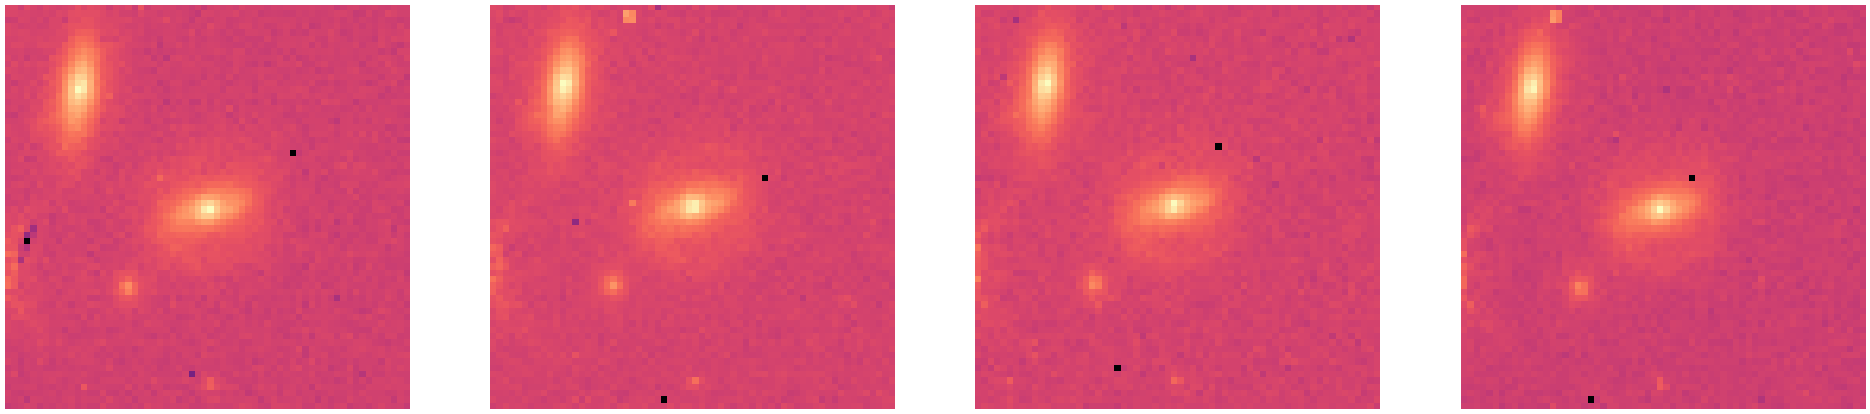

In [433]:
fig, axs = plt.subplots(1, len(wcs_list), figsize=(6*len(wcs_list), 6))
for i in range(len(wcs_list)):
    axs[i].imshow(observations[i], cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-2, clip=True))
    axs[i].axis("off")

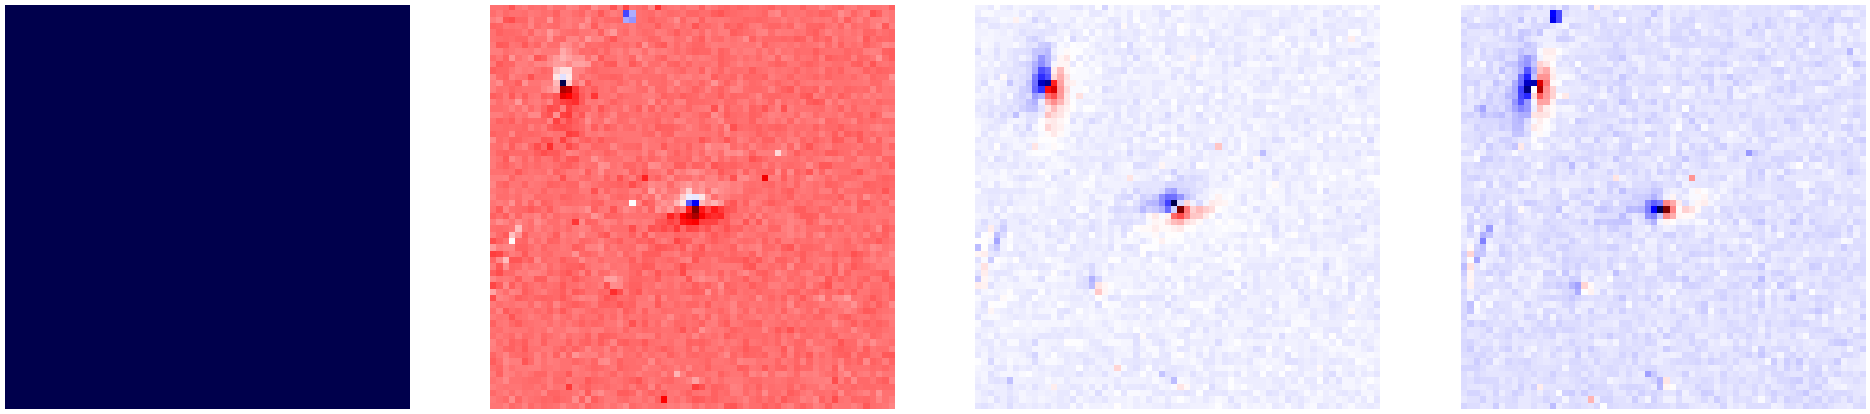

In [447]:
fig, axs = plt.subplots(1, len(wcs_list), figsize=(6*len(wcs_list), 6))
for i in range(len(wcs_list)):
    axs[i].imshow(observations[0] - observations[i], cmap="seismic")
    axs[i].axis("off")

# Checking Alignement with $\chi^2$
We need to align using the WCS world to pixel methods, which I do not wish to reimplement in torch. Anyways, we know the solution should be close to no shift and same orientation for each cutouts, so gridding a likelihood around our guess value will be sophisticated enough to solve this. 

To accomplish the alignement, we will try to minimize a chi squared based on a rough estimate of the noise level the each observations and based on a bilinear interpolation of each images onto the reference WCS. 

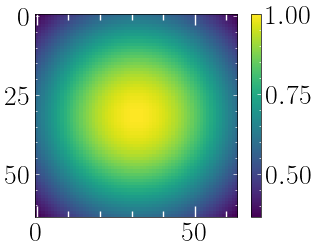

In [434]:
pixels = observations.shape[2]

def forward(shift_x, shift_y, theta, i, i_ref):
    # assert i != i_ref
    wcs_ref = wcs_list[i_ref]
    wcs_target = wcs_list[i]
    hdr = wcs_target.to_header(True) # True makes it so that we have the SIP coefficients

    pc = wcs_target.pixel_scale_matrix
    rotation = np.array([[np.cos(theta), -np.sin(theta)],
                         [np.sin(theta), np.cos(theta)]])
    
    new_pc = rotation @ pc
    hdr["PC1_1"] = new_pc[0, 0]
    hdr["PC1_2"] = new_pc[0, 1]
    hdr["PC2_1"] = new_pc[1, 0]
    hdr["PC2_2"] = new_pc[1, 1]
    hdr["CRVAL1"] = hdr["CRVAL1"] + shift_y / 3600 # arcsec to deg
    hdr["CRVAL2"] = hdr["CRVAL2"] + shift_x / 3600
    # make a new wcs based on shift and rotation of the model
    new_wcs = WCS(hdr)
    y_target = observations[i]

    # Construct coordinate grid of reference observation
    u = np.arange(wcs_ref.pixel_shape[0])# + 0.5 Should not add this 0.5 when making coordinates!!
    v = np.arange(wcs_ref.pixel_shape[1])# + 0.5
    u, v = np.meshgrid(u, v, indexing="ij")
    # Then map to reference WCS
    world = wcs_ref.pixel_to_world(u, v)
    # Then map to target pixel grid
    pixel_x, pixel_y = np.stack(new_wcs.world_to_pixel(world), axis=0)
    
    # Finally interpolate data on this coordinate system
    y = interpolate(y_target, pixel_x, pixel_y)
    return y.reshape(*wcs_ref.pixel_shape)


# Create a tapering mask to avoind edge effects in chi squared
x = np.linspace(-1, 1, pixels)
x, y = np.meshgrid(x, x)
r = x**2 + y**2
mask = np.exp(-0.5 * r)
mask /= mask.max() # sets mask to 1

plt.imshow(mask)
plt.colorbar()

std = 0.2
def chi_squared(shift_x, shift_y, theta, i, i_ref):
    y_ref = observations[i_ref]
    return np.sum((mask * (y_ref - forward(shift_x, shift_y, theta, i, i_ref)))**2 / std**2)


# Alignement by gridding the $\chi^2$ (first, make rough grid to find points of interest)

In [435]:
pixel_scale_x, pixel_scale_y = proj_plane_pixel_scales(wcs_list[0]) * 3600 # we get a rough estimate of the size of a pixel

N_shift = 11 # We search N^3 points for each cutout! So be careful with this number
N_theta = 5 # also, make the number odd so they include 0

# Search radius is defined here
npix = 8
dx = 2*npix * pixel_scale_x / N_shift
dy = 2*npix * pixel_scale_x / N_shift
theta_max = 0.1

# Make an initial search radius
shift_x_grid = np.linspace(-1, 1, N_shift) * npix * pixel_scale_x
shift_y_grid = np.linspace(-1, 1, N_shift) * npix * pixel_scale_y
theta_grid = np.linspace(-1, 1, N_theta) * theta_max # careful, chi sq is very senstive to a global rotation of the coordinate system

i_ref = 1
chi_sq1 = {i: np.zeros((N_shift, N_shift, N_theta)) for i in range(len(wcs_list))}
for i in tqdm(range(len(wcs_list))):
    if i == i_ref: # no need to self align the reference image
        continue
    for j, shift_x in enumerate(shift_x_grid):
        for k, shift_y in enumerate(shift_y_grid):
            for ell, theta in enumerate(theta_grid):
                chi_sq1[i][j, k, ell] = chi_squared(shift_x, shift_y, theta, i, i_ref) # Self alignement is interesting to test if the forward model is good

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:17<00:00,  4.38s/it]


Best parameters 0
Shift x: 0.0 | Shift y: 0.1935003538354451 | theta: 0.0 | chi sq 525.2926799651614
Best parameters 2
Shift x: 0.0 | Shift y: 0.1935003538354451 | theta: 0.0 | chi sq 551.7160341635189
Best parameters 3
Shift x: 0.0 | Shift y: 0.5805010615063348 | theta: 0.0 | chi sq 597.4813654858723


Text(0.5, 0.98, 'Alignment $\\chi^2$ surface with index 1')

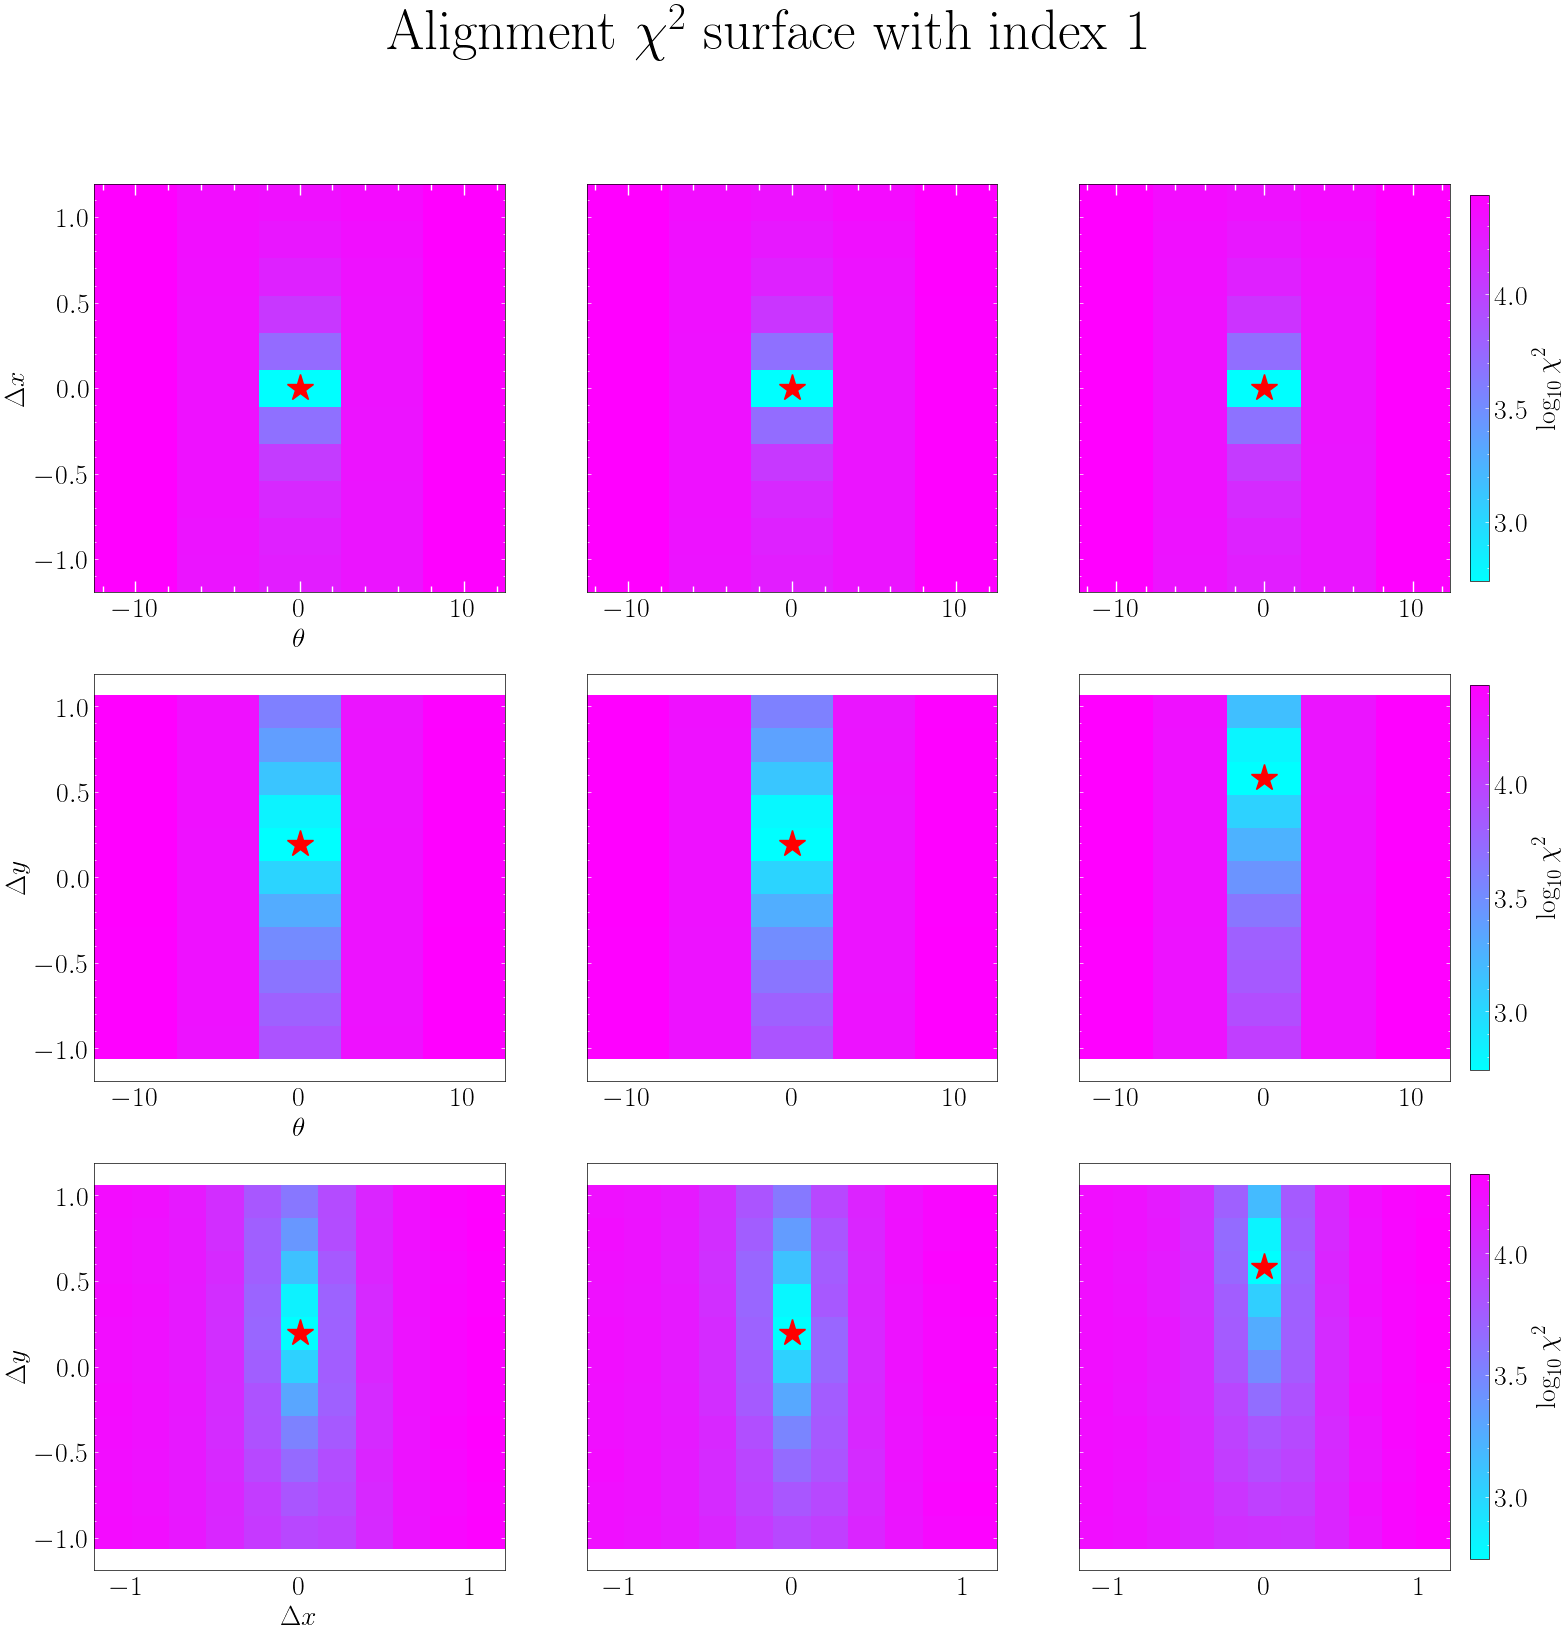

In [436]:
fig, axs = plt.subplots(3, len(wcs_list)-1, figsize=(6 * len(wcs_list)-6, 18), sharey=True)
for i in range(3):
    index = 0
    for j in range(len(wcs_list)):
        if j == i_ref:
            continue
        ll = chi_sq1[j]
        # We slice the likelihood at the dimension where the minimum is
        ii, jj, kk = np.unravel_index(np.argmin(ll), (N_shift, N_shift, N_theta))
        if i == 0:
            print(f"Best parameters {j}")
            print(f"Shift x: {shift_x_grid[ii]} | Shift y: {shift_y_grid[jj]} | theta: {theta_grid[kk]} | chi sq {ll[ii, jj, kk]}")
        if i == 0:
            ll = ll[:, jj]
            x, y = np.meshgrid(theta_grid * 100, shift_x_grid)
            axs[i, index].plot(theta_grid[kk]*100, shift_x_grid[ii], "r*", markersize=20)

        elif i == 1:
            ll = ll[ii]
            x, y = np.meshgrid(theta_grid * 100, shift_y_grid)
            axs[i, index].plot(theta_grid[kk]*100, shift_y_grid[jj], "r*", markersize=20)

        elif i == 2:
            ll = ll[..., kk]
            x, y = np.meshgrid(shift_x_grid, shift_y_grid, indexing="ij")
            axs[i, index].plot(shift_x_grid[ii], shift_y_grid[jj], "r*", markersize=20)
        im = axs[i, index].pcolormesh(x, y, np.log10(ll), cmap="cool")
        index += 1
        if j == len(wcs_list) - 2:
            plt.colorbar(im, ax=axs[i, j], fraction=0.047, label=r"$\log_{10} \chi^2$")

axs[0, 0].set_ylabel(r"$\Delta x$")
axs[1, 0].set_ylabel(r"$\Delta y$")
axs[0, 0].set_xlabel(r"$\theta$")
axs[1, 0].set_xlabel(r"$\theta$")
axs[2, 0].set_ylabel(r"$\Delta y$")
axs[2, 0].set_xlabel(r"$\Delta x$")

fig.suptitle(rf"Alignment $\chi^2$ surface with index {i_ref}", fontsize=40)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 46.69it/s]


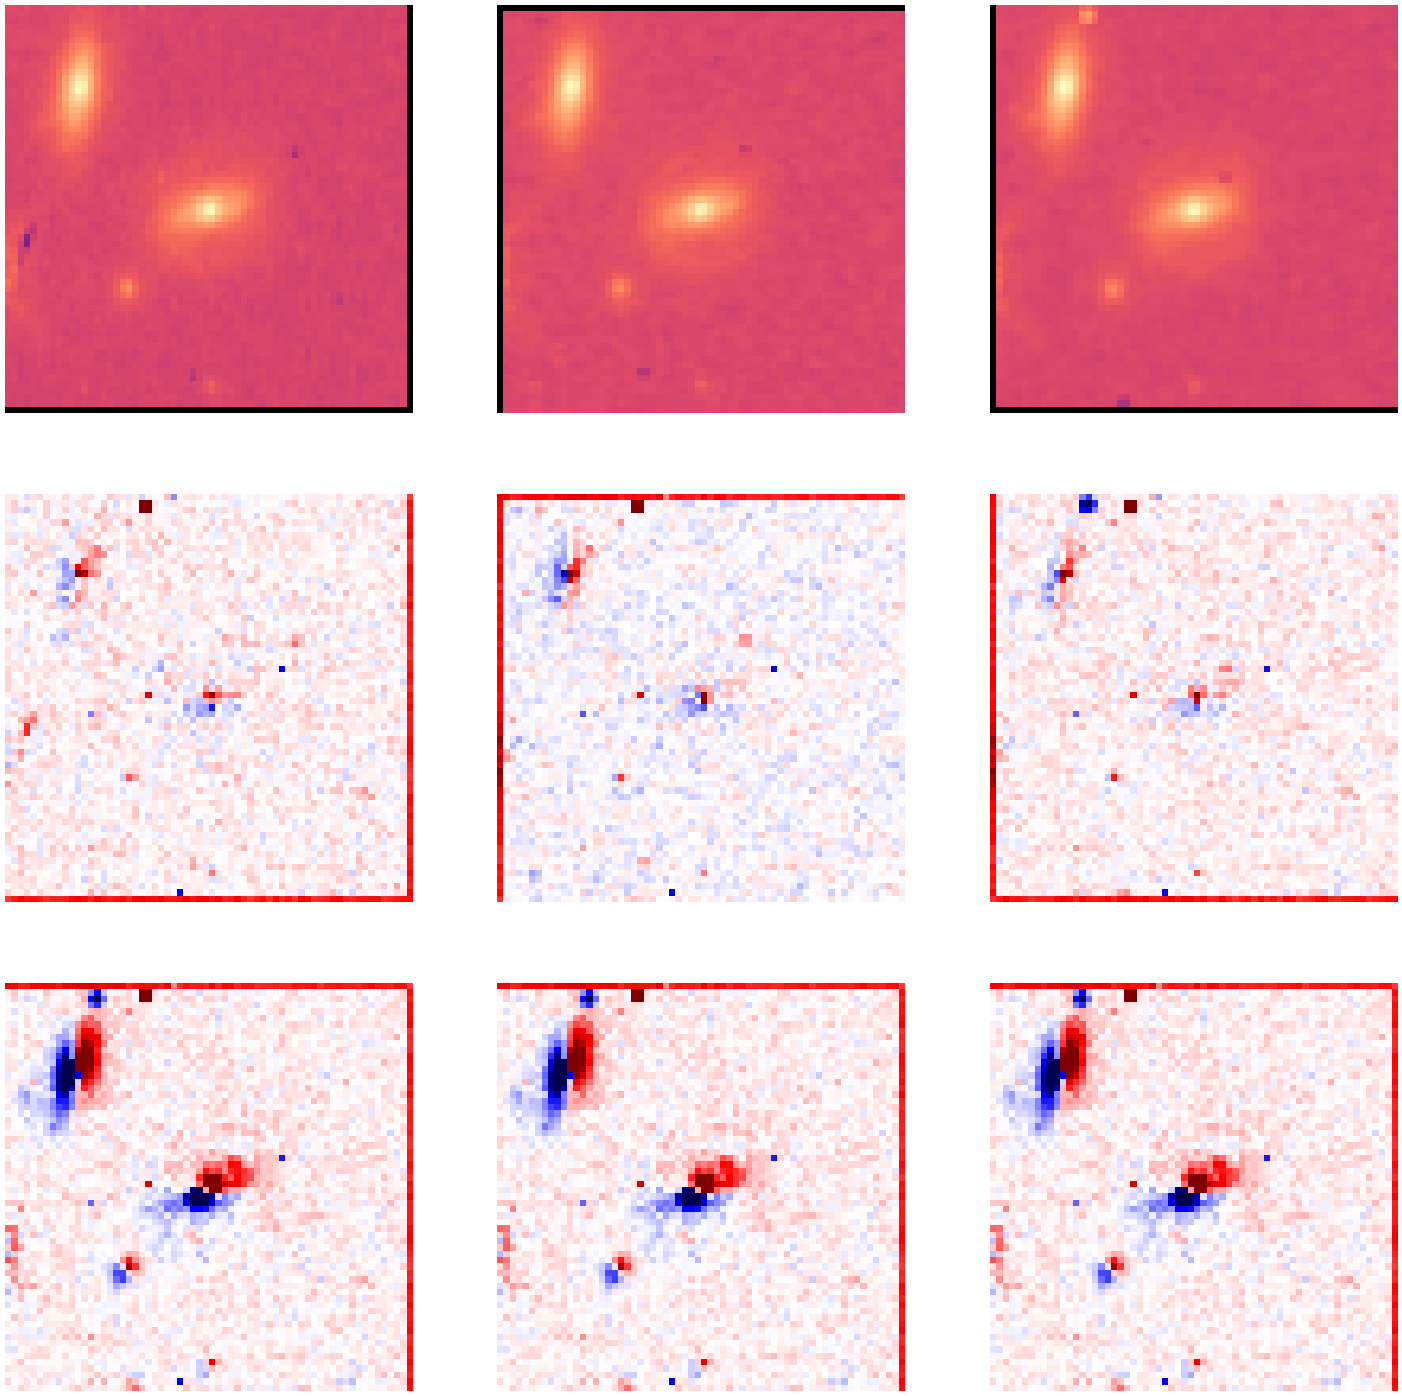

In [437]:
fig, axs = plt.subplots(3, len(wcs_list)-1, figsize=(6 * len(wcs_list)-6, 18), sharey=True)


index = 0
for i in tqdm(range(len(wcs_list))):
    if i == i_ref:
        continue
    ll = np.array(chi_sq1[i])
    ii, jj, kk = np.unravel_index(np.argmin(ll), (N_shift, N_shift, N_theta))
    y = forward(shift_x_grid[ii], shift_y_grid[jj], theta_grid[kk], i, i_ref)
    y_nothing = forward(0, 0, 0, i, i_ref)
    
    axs[0, index].imshow(y, cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-2, clip=True))
    axs[1, index].imshow(observations[i_ref] - y, cmap="seismic", vmin=-1, vmax=1)
    axs[2, index].imshow(observations[i_ref] - y_nothing, cmap="seismic", vmin=-1, vmax=1)
    index += 1
        
for i in range(3):
    for j in range(len(wcs_list)-1):
        axs[i, j].axis("off")

# Run single chain MCMC around point of interest

In [438]:
best_x = []
best_y = []
best_theta = []

for j in range(len(wcs_list)):
    if j == i_ref:
        best_x.append(None)
        best_y.append(None)
        best_theta.append(None)
        continue
    # # Getting best guess from the grid above
    ll = chi_sq1[j]
    # We slice the likelihood at the dimension where the minimum is
    ii, jj, kk = np.unravel_index(np.argmin(ll), (N_shift, N_shift, N_theta))
    best_x.append(shift_x_grid[ii])
    best_y.append(shift_y_grid[jj])
    best_theta.append(theta_grid[kk])
    
    ## Getting the best guess from a previous MCMC chain (comment if they dont exist yet
    # ll = chi_sq[j]
    # best_index = np.argmin(ll)
    # best_x.append(xs[j][best_index])
    # best_y.append(ys[j][best_index])
    # best_theta.append(thetas[j][best_index])

    print(f"Best parameters {j}")
    print(f"Shift x: {best_x[-1]} | Shift y: {best_y[-1]} | theta: {best_theta[-1]} | chi sq {np.min(ll)}")

Best parameters 0
Shift x: 0.0 | Shift y: 0.1935003538354451 | theta: 0.0 | chi sq 525.2926799651614
Best parameters 2
Shift x: 0.0 | Shift y: 0.1935003538354451 | theta: 0.0 | chi sq 551.7160341635189
Best parameters 3
Shift x: 0.0 | Shift y: 0.5805010615063348 | theta: 0.0 | chi sq 597.4813654858723


In [439]:
def mcmc_step(epsilon, x, y, theta, i, i_ref):
    xp = x + np.random.normal() * epsilon[0]
    yp = y + np.random.normal() * epsilon[1]
    theta_p = theta + np.random.normal() * epsilon[2]
    
    ll_current = - chi_squared(x, y, theta, i, i_ref)
    ll_proposed = - chi_squared(xp, yp, theta_p, i, i_ref)
    
    ratio = ll_proposed - ll_current
    accept = np.log(np.random.uniform()) < ratio
    if accept:
        return xp, yp, theta_p, accept, -ll_proposed
    else:
        return x, y, theta, accept, -ll_current

In [440]:
chi_sq = {i: [] for i in range(len(wcs_list))}
xs = {i: [] for i in range(len(wcs_list))}
ys = {i: [] for i in range(len(wcs_list))}
thetas = {i: [] for i in range(len(wcs_list))}

x = best_x[i]
y = best_y[i]
theta = best_theta[i]

i_ref = 1


In [441]:
epsilon = [1e-4, 1e-4, 1e-6]
N = 5000 # length of an MCMC chain

# We do the for loop by hand otherwise pbar is destroyed in jupyter :(
i = 0
x = best_x[i]
y = best_y[i]
theta = best_theta[i]
acceptance = 1
for j in (pbar := tqdm(range(N))):
    x, y, theta, accept, ll = mcmc_step(epsilon, x, y, theta, i, i_ref)
    acceptance = (acceptance * (j + 1) + accept) / (j + 2)
    pbar.set_description(f"Acceptance {acceptance:.2f}")
    chi_sq[i].append(ll)
    xs[i].append(x)
    ys[i].append(y)
    thetas[i].append(theta)
    

Acceptance 0.95: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:58<00:00, 42.25it/s]


In [442]:
epsilon = [5e-5, 5e-5, 1e-6]

i = 2
x = best_x[i]
y = best_y[i]
theta = best_theta[i]
acceptance = 1
for j in (pbar := tqdm(range(N))):
    x, y, theta, accept, ll = mcmc_step(epsilon, x, y, theta, i, i_ref)
    acceptance = (acceptance * (j + 1) + accept) / (j + 2)
    pbar.set_description(f"Acceptance {acceptance:.2f}")
    chi_sq[i].append(ll)
    xs[i].append(x)
    ys[i].append(y)
    thetas[i].append(theta)

Acceptance 0.95: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:52<00:00, 44.36it/s]


In [443]:
epsilon = [5e-5, 5e-5, 1e-6]

i = 3
x = best_x[i]
y = best_y[i]
theta = best_theta[i]

acceptance = 1
for j in (pbar := tqdm(range(N))):
    x, y, theta, accept, ll = mcmc_step(epsilon, x, y, theta, i, i_ref)
    acceptance = (acceptance * (j + 1) + accept) / (j + 2)
    pbar.set_description(f"Acceptance {acceptance:.2f}")
    chi_sq[i].append(ll)
    xs[i].append(x)
    ys[i].append(y)
    thetas[i].append(theta)

Acceptance 0.95: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:53<00:00, 44.12it/s]


Best parameters 0
Shift x: -0.0015632741197403037 | Shift y: 0.21012441861573816 | theta: -0.00020795381369176683 | chi sq 481.0896326796053
Best parameters 2
Shift x: 0.009571440152612885 | Shift y: 0.19308239168199504 | theta: -0.0002544089322810256 | chi sq 502.16534266293195
Best parameters 3
Shift x: 0.0016704272934646978 | Shift y: 0.5856860355199981 | theta: -0.0002113453706836318 | chi sq 560.7226793289688


Text(0.5, 0.98, 'MCMC chains')

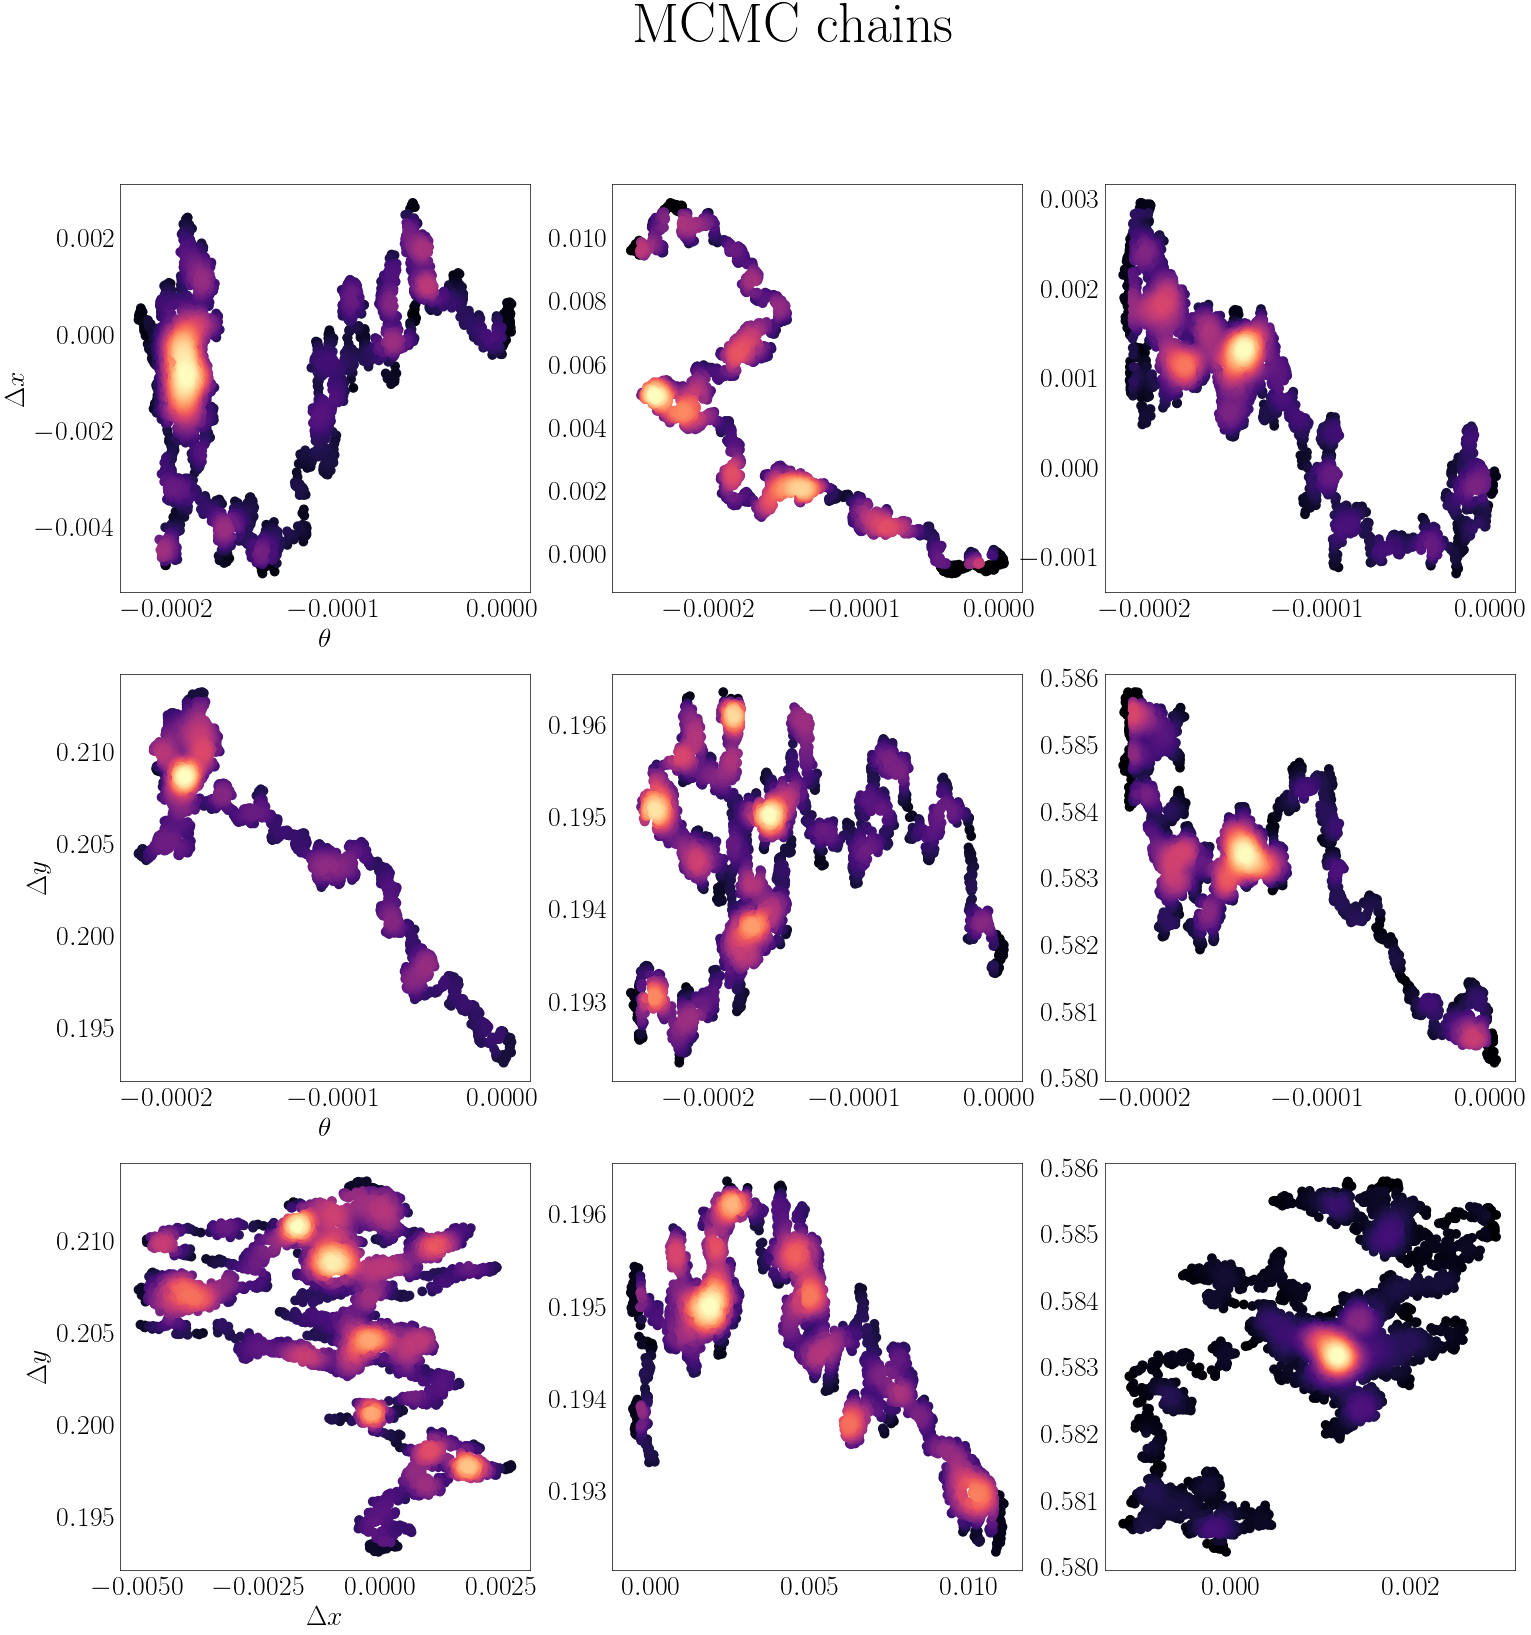

In [444]:
fig, axs = plt.subplots(3, len(wcs_list)-1, figsize=(6 * len(wcs_list)-6, 18))
for i in range(3):
    index = 0
    for j in range(len(wcs_list)):
        if j == i_ref:
            continue
        ll = chi_sq[j]
        best_index = np.argmin(ll)
        if i == 0:
            print(f"Best parameters {j}")
            print(f"Shift x: {xs[j][best_index]} | Shift y: {ys[j][best_index]} | theta: {thetas[j][best_index]} | chi sq {ll[best_index]}")
        if i == 0:
            points = np.stack([thetas[j], xs[j]], axis=1)
        elif i == 1:
            points = np.stack([thetas[j], ys[j]], axis=1)
        elif i == 2:
            points = np.stack([xs[j], ys[j]], axis=1)
        density_scatter(points, ax=axs[i, index])
        index += 1

axs[0, 0].set_ylabel(r"$\Delta x$")
axs[1, 0].set_ylabel(r"$\Delta y$")
axs[0, 0].set_xlabel(r"$\theta$")
axs[1, 0].set_xlabel(r"$\theta$")
axs[2, 0].set_ylabel(r"$\Delta y$")
axs[2, 0].set_xlabel(r"$\Delta x$")

fig.suptitle(rf"MCMC chains", fontsize=40)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 49.24it/s]


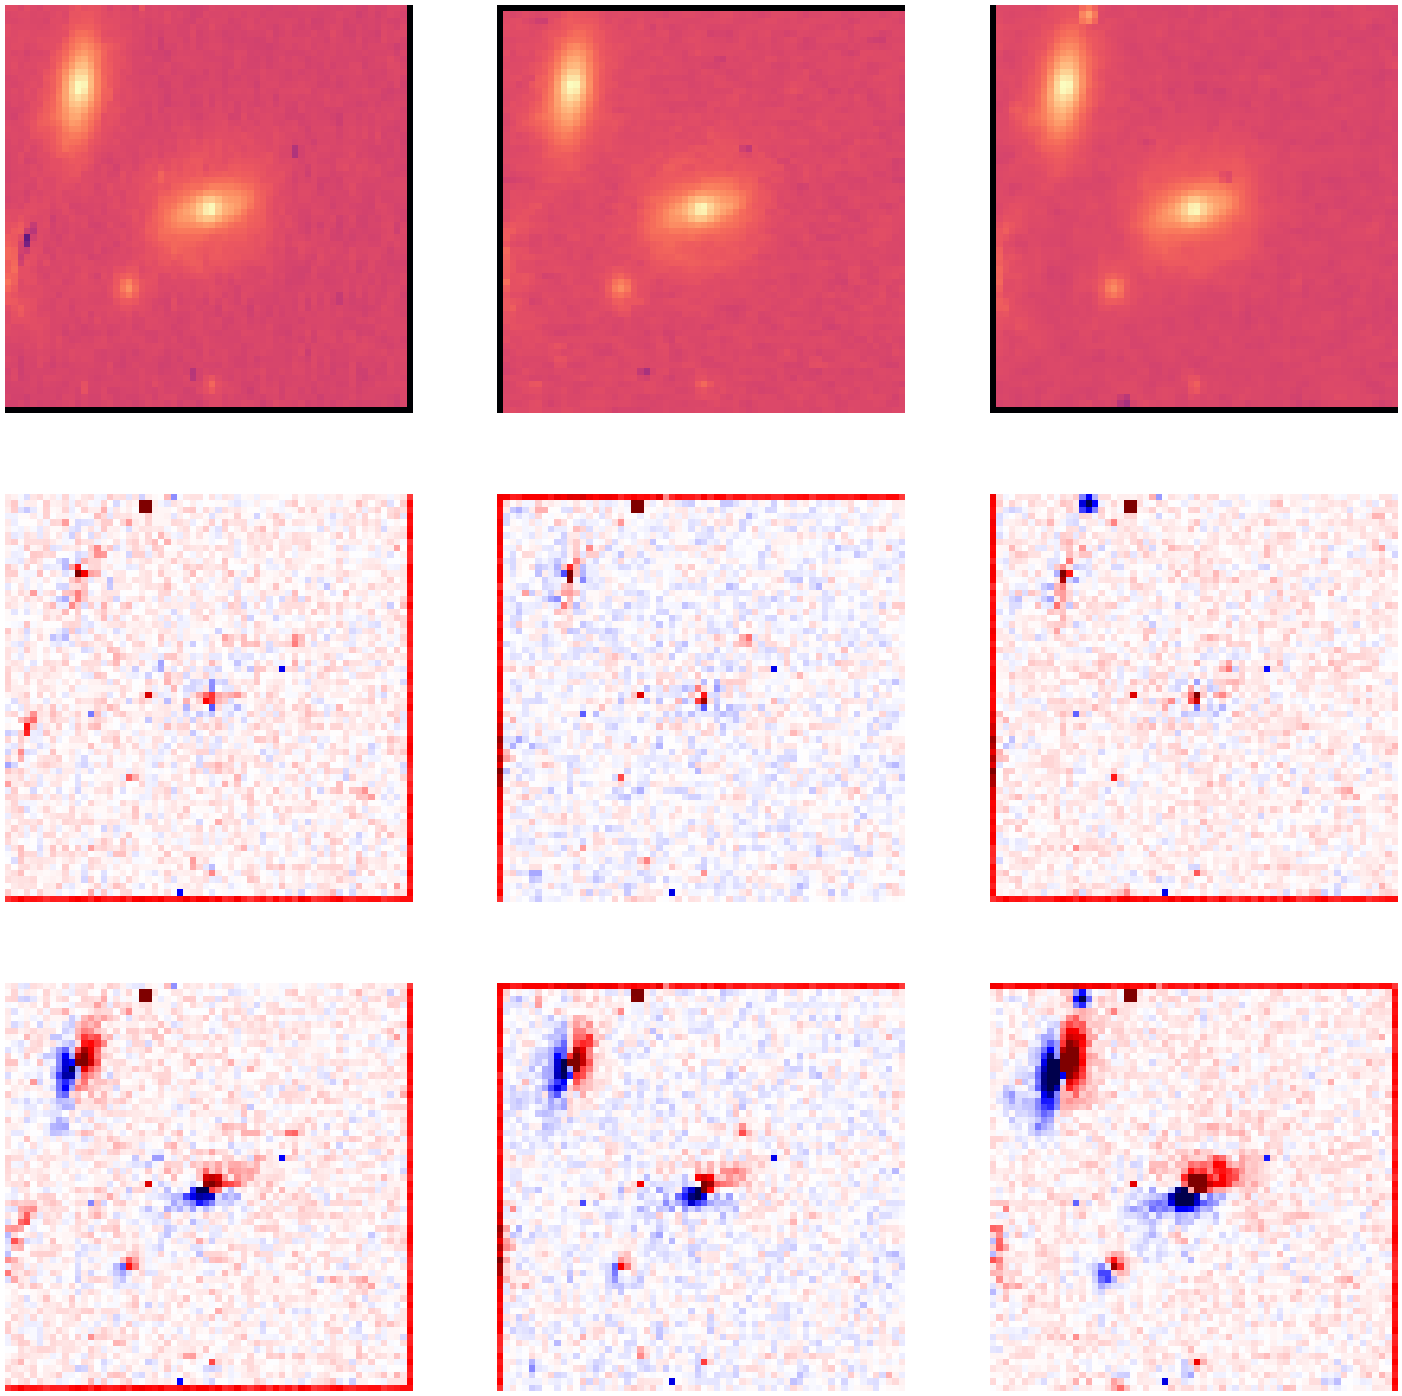

In [445]:
fig, axs = plt.subplots(3, len(wcs_list)-1, figsize=(6 * len(wcs_list)-6, 18), sharey=True)

index = 0
for i in tqdm(range(len(wcs_list))):
    if i == i_ref:
        continue
    ll = np.array(chi_sq[i])
    best_index = np.argmin(ll)
    y = forward(xs[i][best_index], ys[i][best_index], thetas[i][best_index], i, i_ref)
    y_nothing = forward(0, 0, 0, i, i_ref)
    
    axs[0, index].imshow(y, cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-2, clip=True))
    axs[1, index].imshow(observations[i_ref] - y, cmap="seismic", vmin=-1, vmax=1)
    axs[2, index].imshow(observations[i_ref] - y_nothing, cmap="seismic", vmin=-1, vmax=1)
    index += 1
        
for i in range(3):
    for j in range(len(wcs_list)-1):
        axs[i, j].axis("off")

# Now save the WCS solution so we can build it back later

In [446]:
for j in range(len(wcs_list)):
    filename = os.path.split(paths[j])[-1]
    if j == i_ref:
        np.savez(f"../data/smacs_{filename}_target{TARGET}_{FILTER}_iref{i_ref}_wcs_solutions.npz", **{"x": 0, "y": 0, "theta": 0})
        continue
    ll = chi_sq[j]
    best_index = np.argmin(ll)
    np.savez(f"../data/smacs_{filename}_target{TARGET}_{FILTER}_iref{i_ref}_wcs_solutions.npz", **{"x": xs[j][best_index], "y": ys[j][best_index], "theta": thetas[j][best_index]})

# Reduce search radius around point of interest

In [100]:
# Assuming i_ref = 1, solution found below on y
best_x = [0, 0, 0, 0]
best_y = [0.58, 0, 0.2725, 0.3775]
best_theta = [0, 0, 0, 0]

In [121]:
pixel_scale_x, pixel_scale_y = proj_plane_pixel_scales(wcs_list[0]) * 3600 # we get a rough estimate of the size of a pixel

N_shift = 21 # We search N^3 points for each cutout! So be careful with this number
N_theta = 21 # also, make the number odd so they include 0

# Search radius is defined here
npix = 0.5
dx = 2*npix * pixel_scale_x / N_shift
dy = 2*npix * pixel_scale_x / N_shift
theta_max = 0.01

# Make an initial search radius


i_ref = 1 # dont change this, since solution assume i_ref = 1
chi_sq = {i: np.zeros((N_shift, N_shift, N_theta)) for i in range(len(wcs_list))}
for i in tqdm(range(len(wcs_list))):
    if i == i_ref: # no need to self align the reference image
        continue
    shift_x_grid = np.linspace(-1, 1, N_shift) * npix * pixel_scale_x + best_x[i]
    shift_y_grid = np.linspace(-1, 1, N_shift) * npix * pixel_scale_y + best_y[i]
    theta_grid = np.linspace(-1, 1, N_theta) * theta_max + best_theta[i]
    for j, shift_x in enumerate(shift_x_grid):
        for k, shift_y in enumerate(shift_y_grid):
            for ell, theta in enumerate(theta_grid):
                chi_sq[i][j, k, ell] = chi_squared(shift_x, shift_y, theta, i, i_ref) # Self alignement is interesting to test if the forward model is good

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [08:17<00:00, 124.30s/it]


Best parameters 0
Shift x: -0.006770017225411655 | Shift y: 0.5860470698040108 | theta: 0.0 | chi sq 658309.6444532558
Best parameters 2
Shift x: 0.020310051676234973 | Shift y: 0.27854706980401084 | theta: -0.0009999999999999998 | chi sq 506303.6612906729
Best parameters 3
Shift x: 0.06093015502870491 | Shift y: 0.3835470698040108 | theta: -0.0019999999999999996 | chi sq 275480.341152919


Text(0.5, 0.98, 'Alignment $\\chi^2$ surface with index 1')

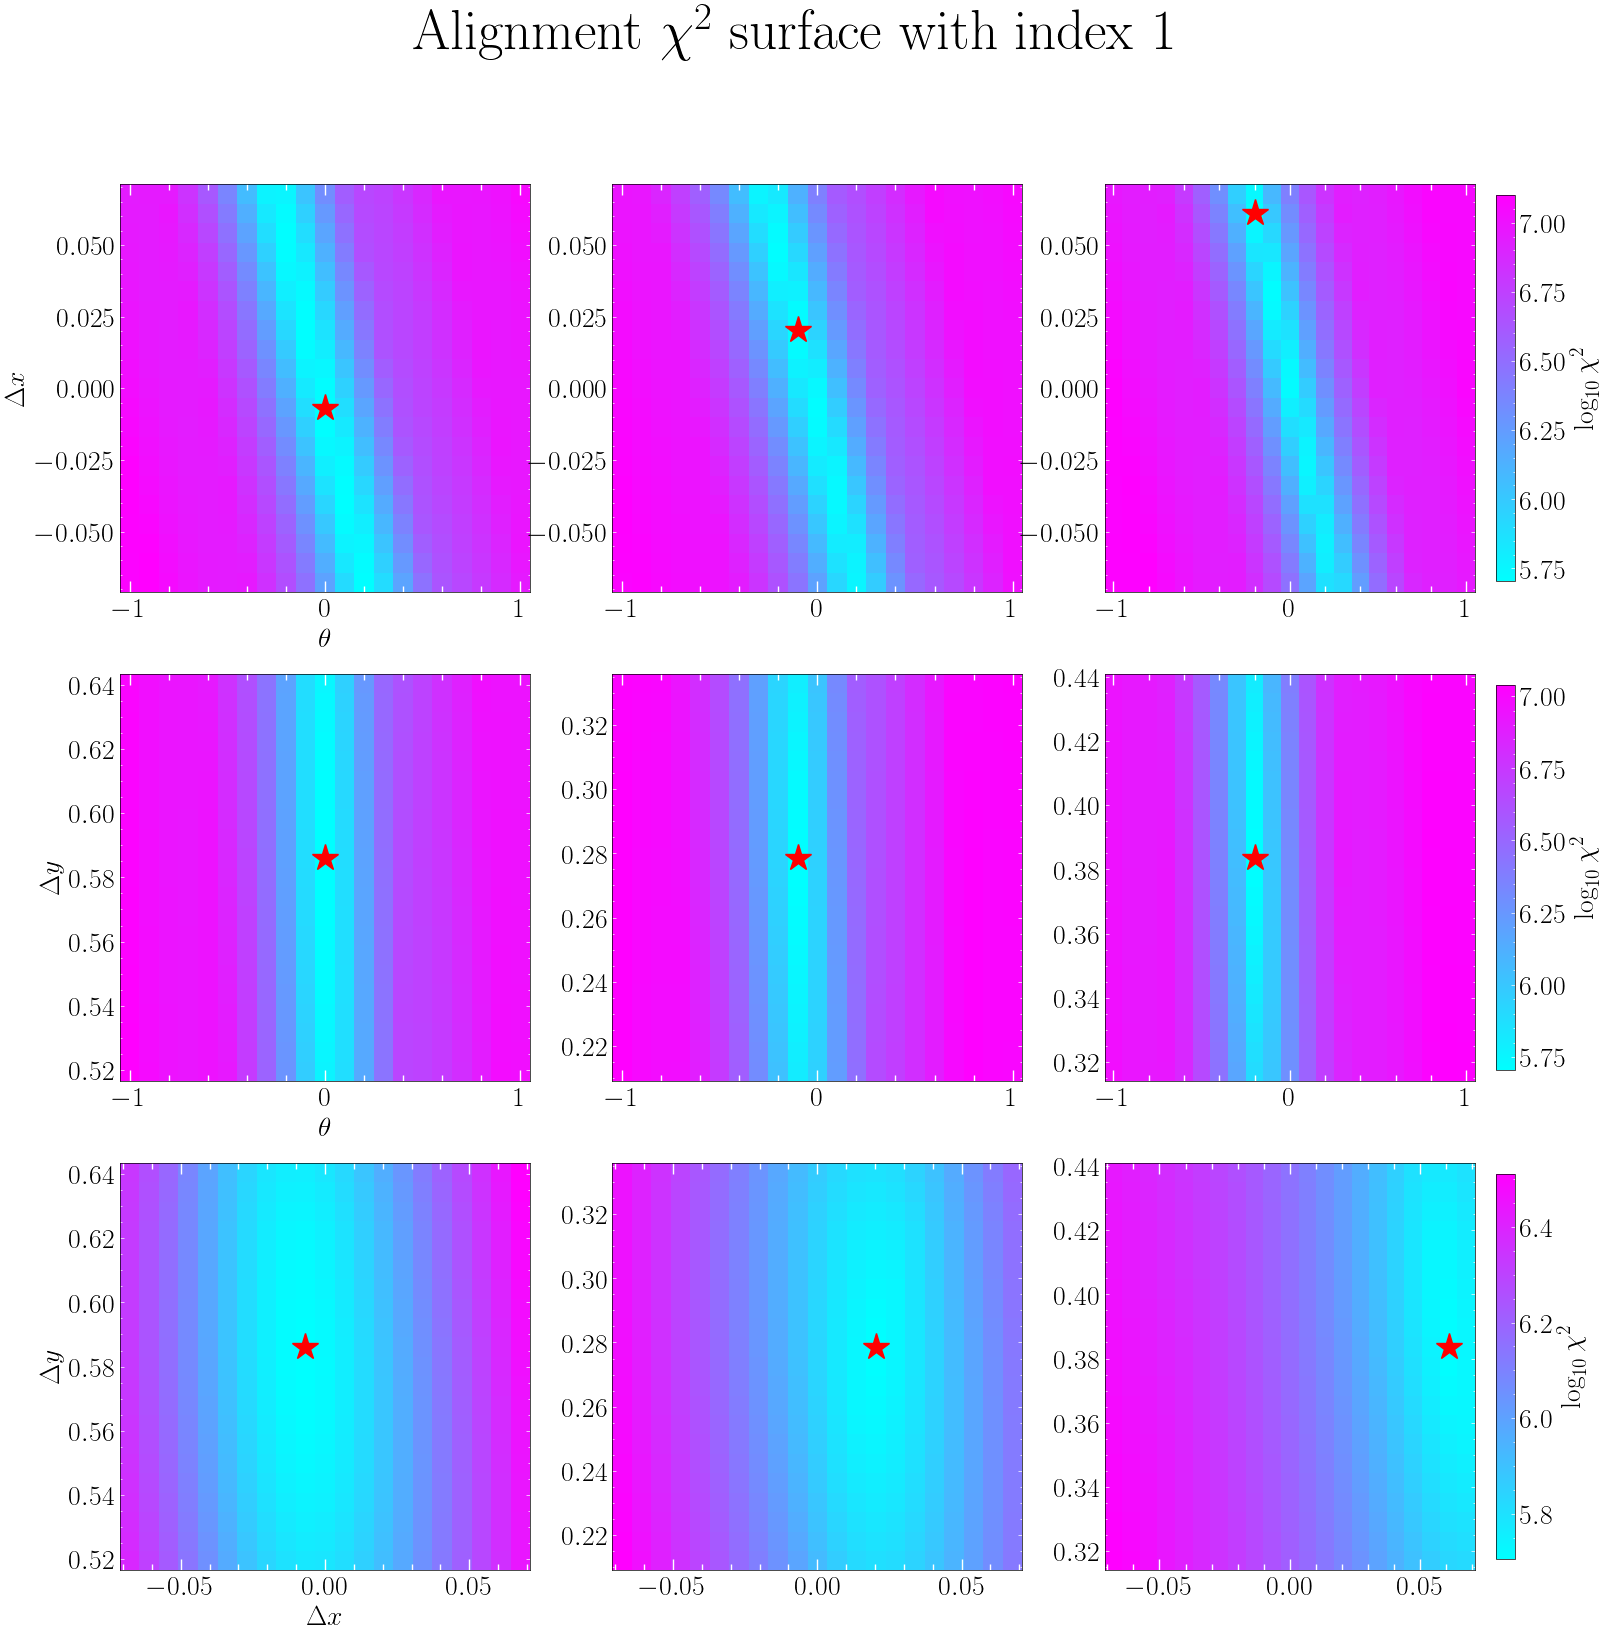

In [141]:
fig, axs = plt.subplots(3, len(wcs_list)-1, figsize=(6 * len(wcs_list)-6, 18))

for i in range(3):
    index = 0
    for j in range(len(wcs_list)):
        if j == i_ref:
            continue
        ll = chi_sq[j]
        # We slice the likelihood at the dimension where the minimum is
        ii, jj, kk = np.unravel_index(np.argmin(ll), (N_shift, N_shift, N_theta))
        
        shift_x_grid = np.linspace(-1, 1, N_shift) * npix * pixel_scale_x + best_x[j]
        shift_y_grid = np.linspace(-1, 1, N_shift) * npix * pixel_scale_y + best_y[j]
        theta_grid = np.linspace(-1, 1, N_theta) * theta_max + best_theta[j]

        if i == 0:
            print(f"Best parameters {j}")
            print(f"Shift x: {shift_x_grid[ii]} | Shift y: {shift_y_grid[jj]} | theta: {theta_grid[kk]} | chi sq {ll[ii, jj, kk]}")
        if i == 0:
            ll = ll[:, jj]
            x, y = np.meshgrid(theta_grid * 100, shift_x_grid)
            axs[i, index].plot(theta_grid[kk]*100, shift_x_grid[ii], "r*", markersize=20)

        elif i == 1:
            ll = ll[ii]
            x, y = np.meshgrid(theta_grid * 100, shift_y_grid)
            axs[i, index].plot(theta_grid[kk]*100, shift_y_grid[jj], "r*", markersize=20)

        elif i == 2:
            ll = ll[..., kk]
            x, y = np.meshgrid(shift_x_grid, shift_y_grid, indexing="ij")
            axs[i, index].plot(shift_x_grid[ii], shift_y_grid[jj], "r*", markersize=20)
        im = axs[i, index].pcolormesh(x, y, np.log10(ll), cmap="cool")
        index += 1
        if j == len(wcs_list) - 2:
            plt.colorbar(im, ax=axs[i, j], fraction=0.047, label=r"$\log_{10} \chi^2$")

axs[0, 0].set_ylabel(r"$\Delta x$")
axs[1, 0].set_ylabel(r"$\Delta y$")
axs[0, 0].set_xlabel(r"$\theta$")
axs[1, 0].set_xlabel(r"$\theta$")
axs[2, 0].set_ylabel(r"$\Delta y$")
axs[2, 0].set_xlabel(r"$\Delta x$")

fig.suptitle(rf"Alignment $\chi^2$ surface with index {i_ref}", fontsize=40)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 33.60it/s]


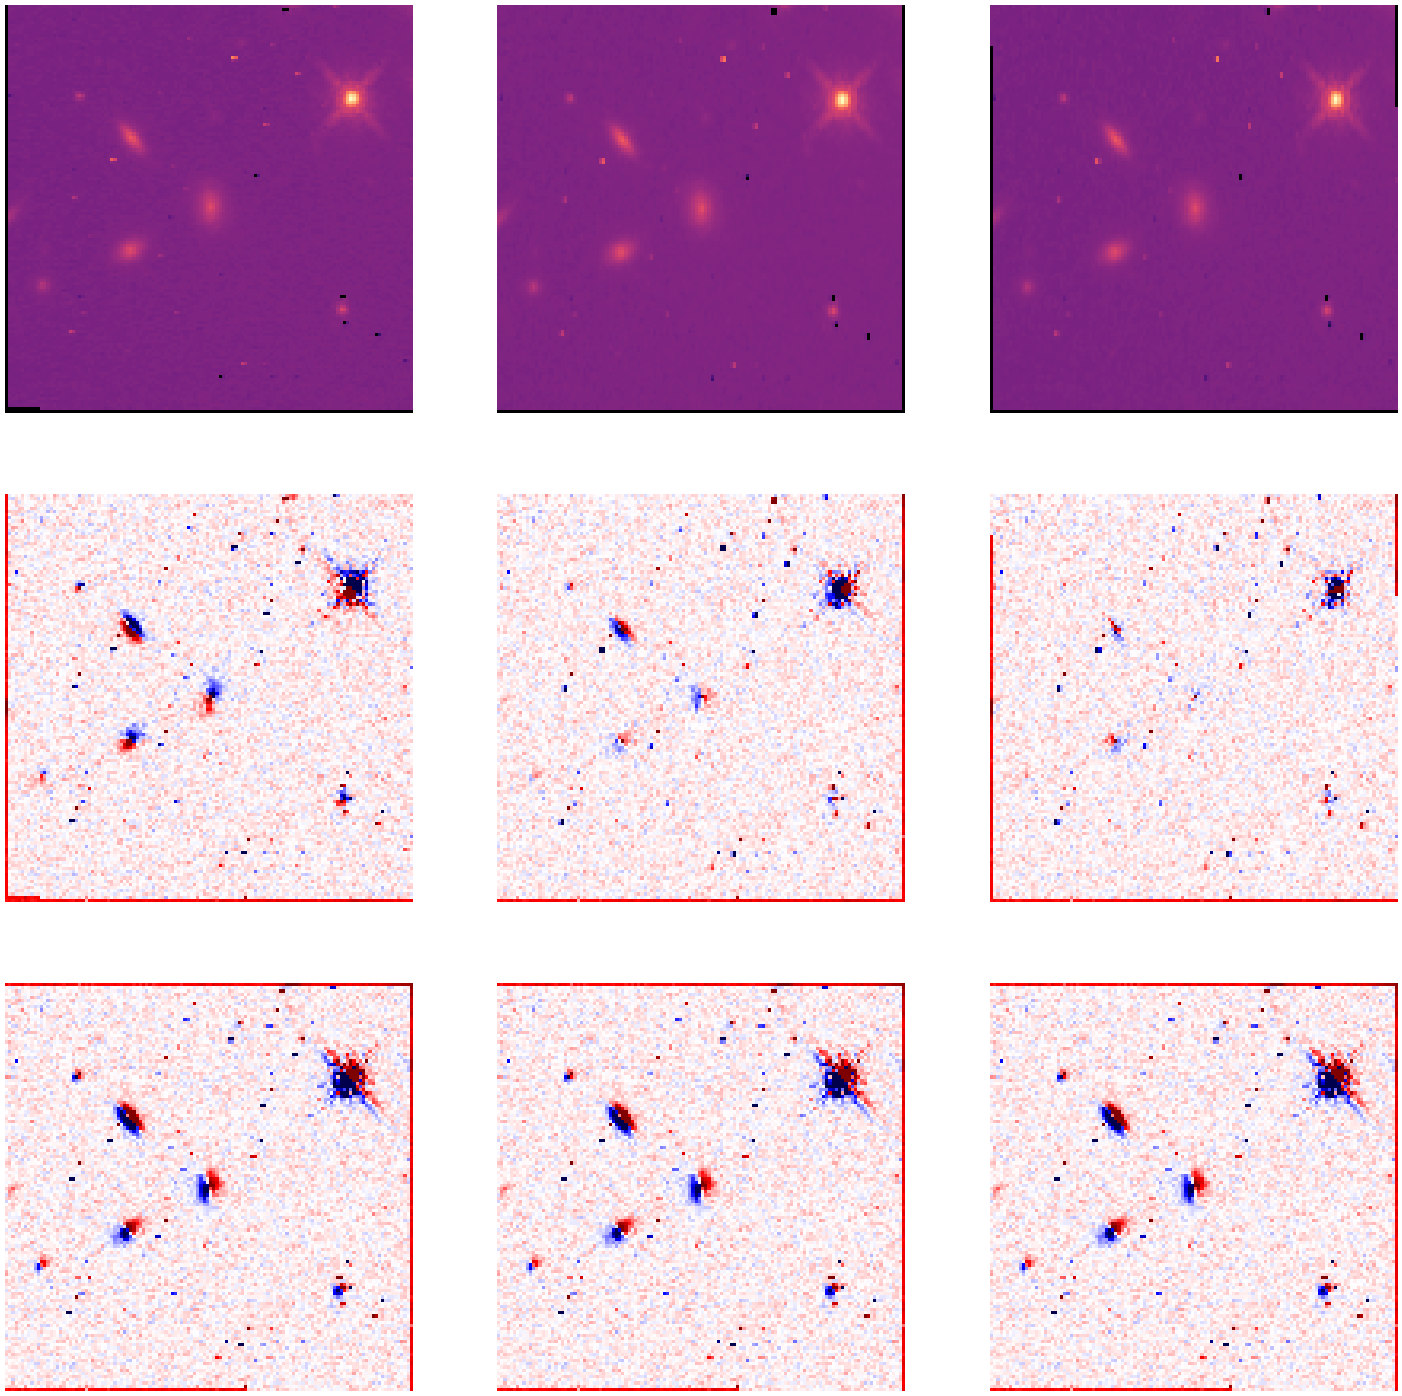

In [142]:
fig, axs = plt.subplots(3, len(wcs_list)-1, figsize=(6 * len(wcs_list)-6, 18), sharey=True)


index = 0
for i in tqdm(range(len(wcs_list))):
    if i == i_ref:
        continue

    shift_x_grid = np.linspace(-1, 1, N_shift) * npix * pixel_scale_x + best_x[i]
    shift_y_grid = np.linspace(-1, 1, N_shift) * npix * pixel_scale_y + best_y[i]
    theta_grid = np.linspace(-1, 1, N_theta) * theta_max + best_theta[i]
        
    ll = np.array(chi_sq[i])
    ii, jj, kk = np.unravel_index(np.argmin(ll), (N_shift, N_shift, N_theta))
    y = forward(shift_x_grid[ii], shift_y_grid[jj], theta_grid[kk], j, i_ref)
    y_nothing = forward(0, 0, 0, j, i_ref)
    
    axs[0, index].imshow(y, cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-2, clip=True))
    axs[1, index].imshow(observations[i_ref] - y, cmap="seismic", vmin=-1, vmax=1)
    axs[2, index].imshow(observations[i_ref] - y_nothing, cmap="seismic", vmin=-1, vmax=1)
    index += 1
        
for i in range(3):
    for j in range(len(wcs_list)-1):
        axs[i, j].axis("off")

# Only search for the sub pixel shift minimum

In [27]:
pixel_scale_x, pixel_scale_y = proj_plane_pixel_scales(wcs_list[0]) * 3600 # we get a rough estimate of the size of a pixel

N_shift = 101 # We search N^2 points for each cutout! So be careful with this number

center_x = [n]

npix = 5
dx = 2*npix * pixel_scale_x / N_shift
dy = 2*npix * pixel_scale_x / N_shift

# Make an initial search radius
shift_x_grid = np.linspace(-1, 1, N_shift) * npix * pixel_scale_x
shift_y_grid = np.linspace(-1, 1, N_shift) * npix * pixel_scale_y

i_ref = 1
chi_sq = {i: np.zeros((N_shift, N_shift)) for i in range(len(wcs_list))}
for i in tqdm(range(len(wcs_list))):
    for j, shift_x in enumerate(shift_x_grid):
        for k, shift_y in enumerate(shift_y_grid):
            chi_sq[i][j, k] = chi_squared(shift_x, shift_y, 0, i, i_ref)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [02:55<00:00, 43.76s/it]


Best parameters 0
Shift x: 0.0 | Shift y: 0.5744961461995458 | chi squared 718166.3211050759
Best parameters 1
Shift x: 0.0 | Shift y: 0.0 | chi squared 749.4822274374271
Best parameters 2
Shift x: 0.0 | Shift y: 0.302366392736603 | chi squared 557284.1620203592
Best parameters 3
Shift x: 0.0 | Shift y: 0.36283967128392364 | chi squared 291093.0859234498


Text(0.5, 0.98, 'Alignment $\\chi^2$ surface')

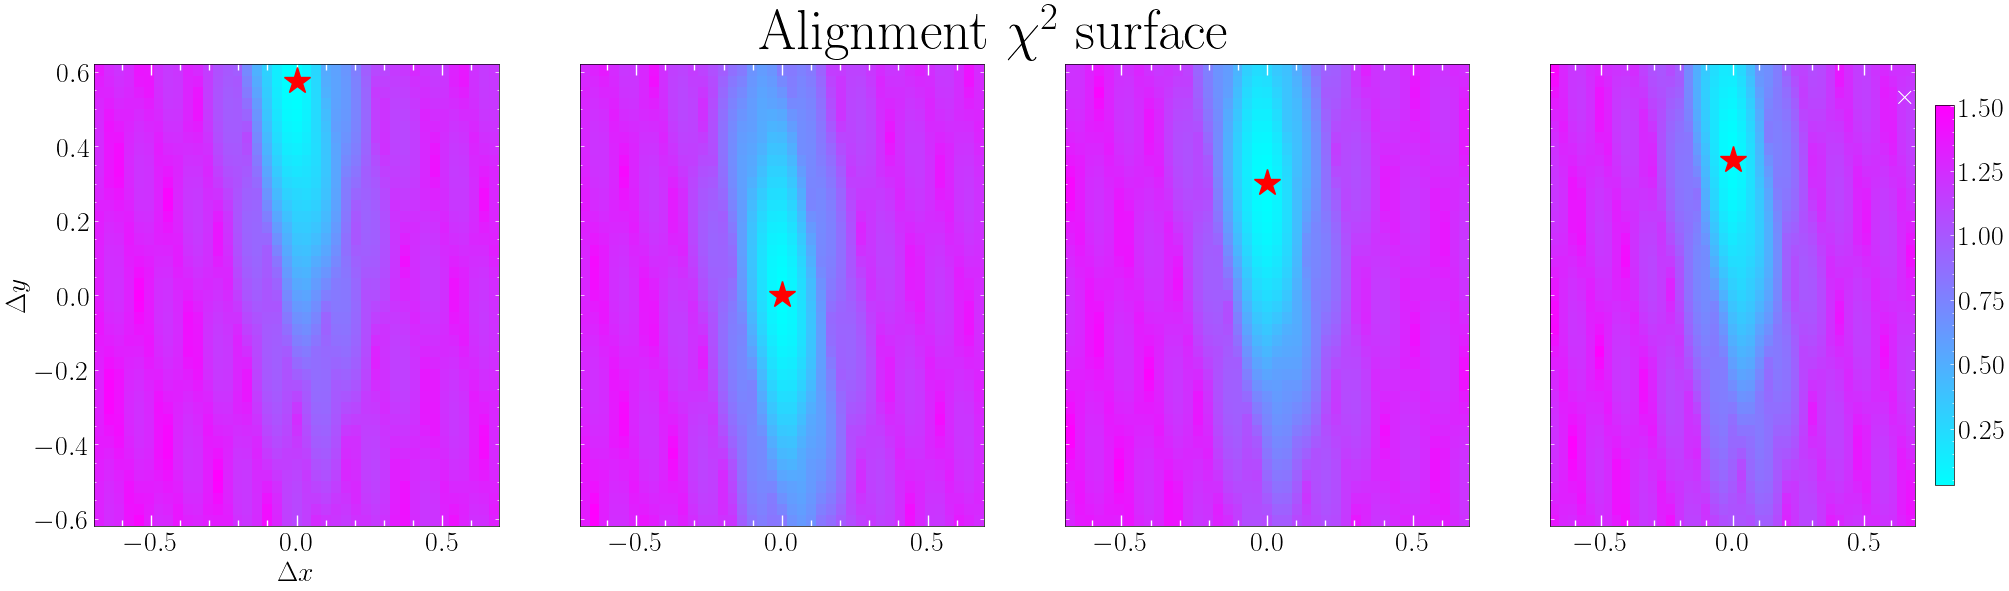

In [445]:
fig, axs = plt.subplots(1, len(wcs_list)-1, figsize=(6 * len(wcs_list), 6), sharey=True)
for j in range(len(wcs_list)):
    ll = np.array(chi_sq[j])
    # We slice the likelihood at the dimension where the minimum is
    ii, jj = np.unravel_index(np.argmin(ll), (N_shift, N_shift))
    print(f"Best parameters {j}")
    print(f"Shift x: {shift_x_grid[ii]} | Shift y: {shift_y_grid[jj]} | chi squared {ll[ii, jj]}")

    x, y = np.meshgrid(shift_x_grid, shift_y_grid, indexing="ij")
    im = axs[j].pcolormesh(x, y, ll, cmap="cool")
    axs[j].plot(shift_x_grid[ii], shift_y_grid[jj], "r*", markersize=20)

    if j == len(wcs_list) - 1:
        plt.colorbar(im, ax=axs[j], fraction=0.047)


axs[0].set_ylabel(r"$\Delta y$")
axs[0].set_xlabel(r"$\Delta x$")

fig.suptitle(r"Alignment $\chi^2$ surface", fontsize=40)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 23.51it/s]


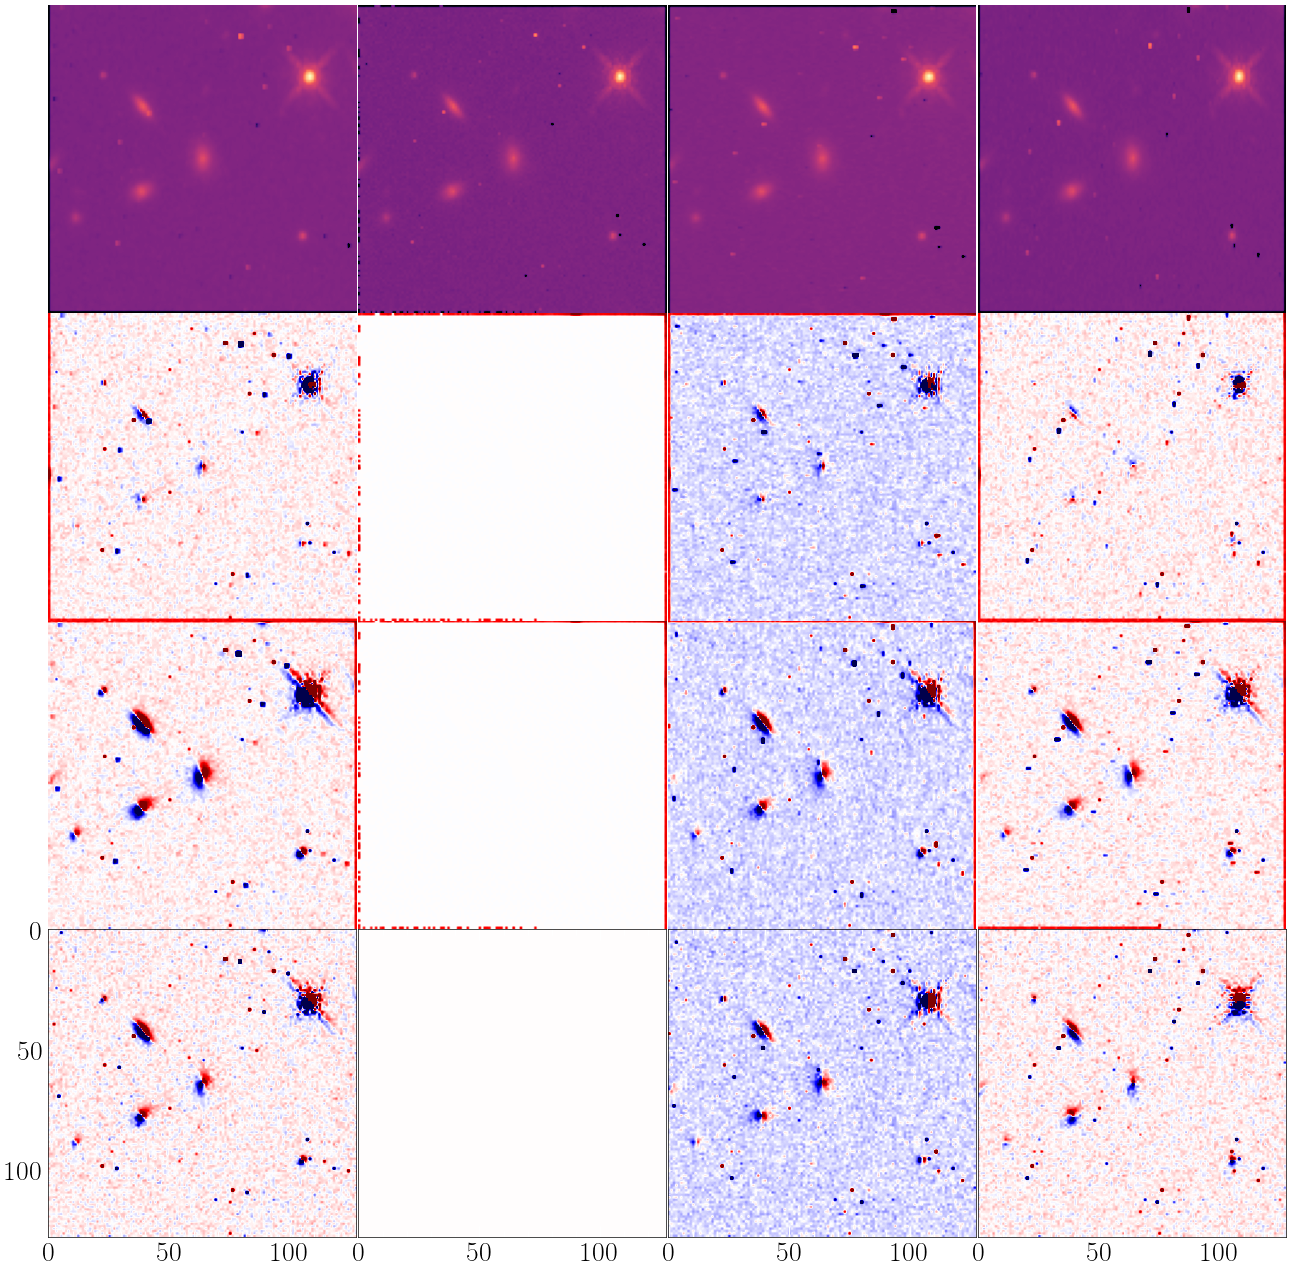

In [29]:
fig, axs = plt.subplots(4, len(wcs_list), figsize=(4 * len(wcs_list), 16), sharey=True)


for i in tqdm(range(len(wcs_list))):
    j = i 
    ll = chi_sq[j]
    ii, jj = np.unravel_index(np.argmin(ll), (N_shift, N_shift))
    y = forward(shift_x_grid[ii], shift_y_grid[jj], 0, j, i_ref)
    y_nothing = forward(0, 0, 0, j, i_ref)
    
    axs[0, i].imshow(y, cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-2, clip=True))
    axs[1, i].imshow(observations[i_ref] - y, cmap="seismic", vmin=-1, vmax=1)
    axs[2, i].imshow(observations[i_ref] - y_nothing, cmap="seismic", vmin=-1, vmax=1)
    axs[3, i].imshow(observations[i_ref] - observations[j], cmap="seismic", vmin=-1, vmax=1)


for i in range(3):
    for j in range(len(wcs_list)):
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

# $\chi^2$ of shift values

In [106]:
N = 401
y_max = 1 # Cannot go too far, otherwise chi squared has weird behavior. 
y_min = 0
y_grid = (np.linspace(-1, 1, N) + 1)/2 * (y_max - y_min) + y_min

i_ref = 1
chi_sq = {i: np.zeros((N)) for i in range(len(wcs_list))}
for i in tqdm(range(len(wcs_list))):
    if i == i_ref:
        continue
    for ell, y in enumerate(y_grid):
        chi_sq[i][ell] = chi_squared(0, y, 0, i, i_ref) # Self alignement is interesting to test if the forward model is good

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:20<00:00,  5.06s/it]


Text(0.5, 0.98, 'Alignment $\\chi^2$ surface')

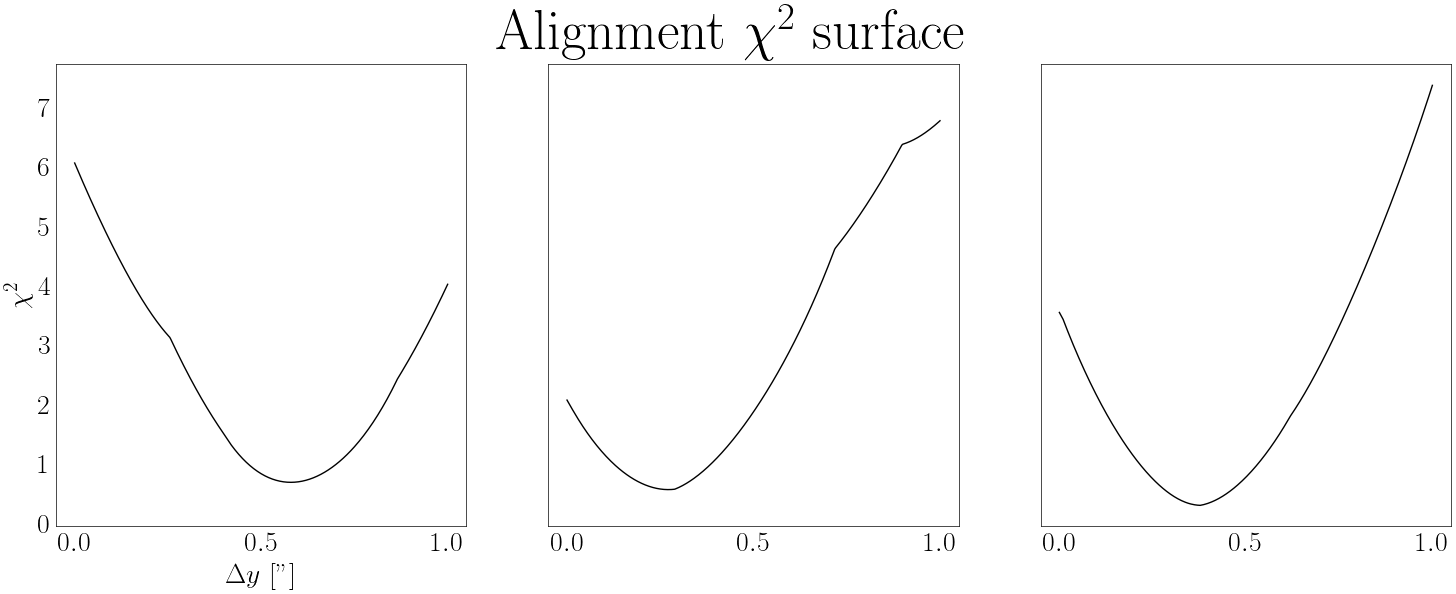

In [107]:
fig, axs = plt.subplots(1, len(wcs_list)-1, figsize=(6 * len(wcs_list)-6, 6), sharey=True)
index = 0
for j in range(len(wcs_list)):
    if j == i_ref:
        continue
    ll = np.array(chi_sq[j])
    # We slice the likelihood at the dimension where the minimum is
    kk = np.unravel_index(np.argmin(ll), (N))
    im = axs[index].plot(y_grid, ll, "k-")
    index += 1

axs[0].set_ylabel(r"$\chi^2$")
axs[0].set_xlabel(r"$\Delta y$ ['']")

fig.suptitle(r"Alignment $\chi^2$ surface", fontsize=40)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 34.41it/s]


Solution for 0 is 0.58
Solution for 2 is 0.2725
Solution for 3 is 0.3775


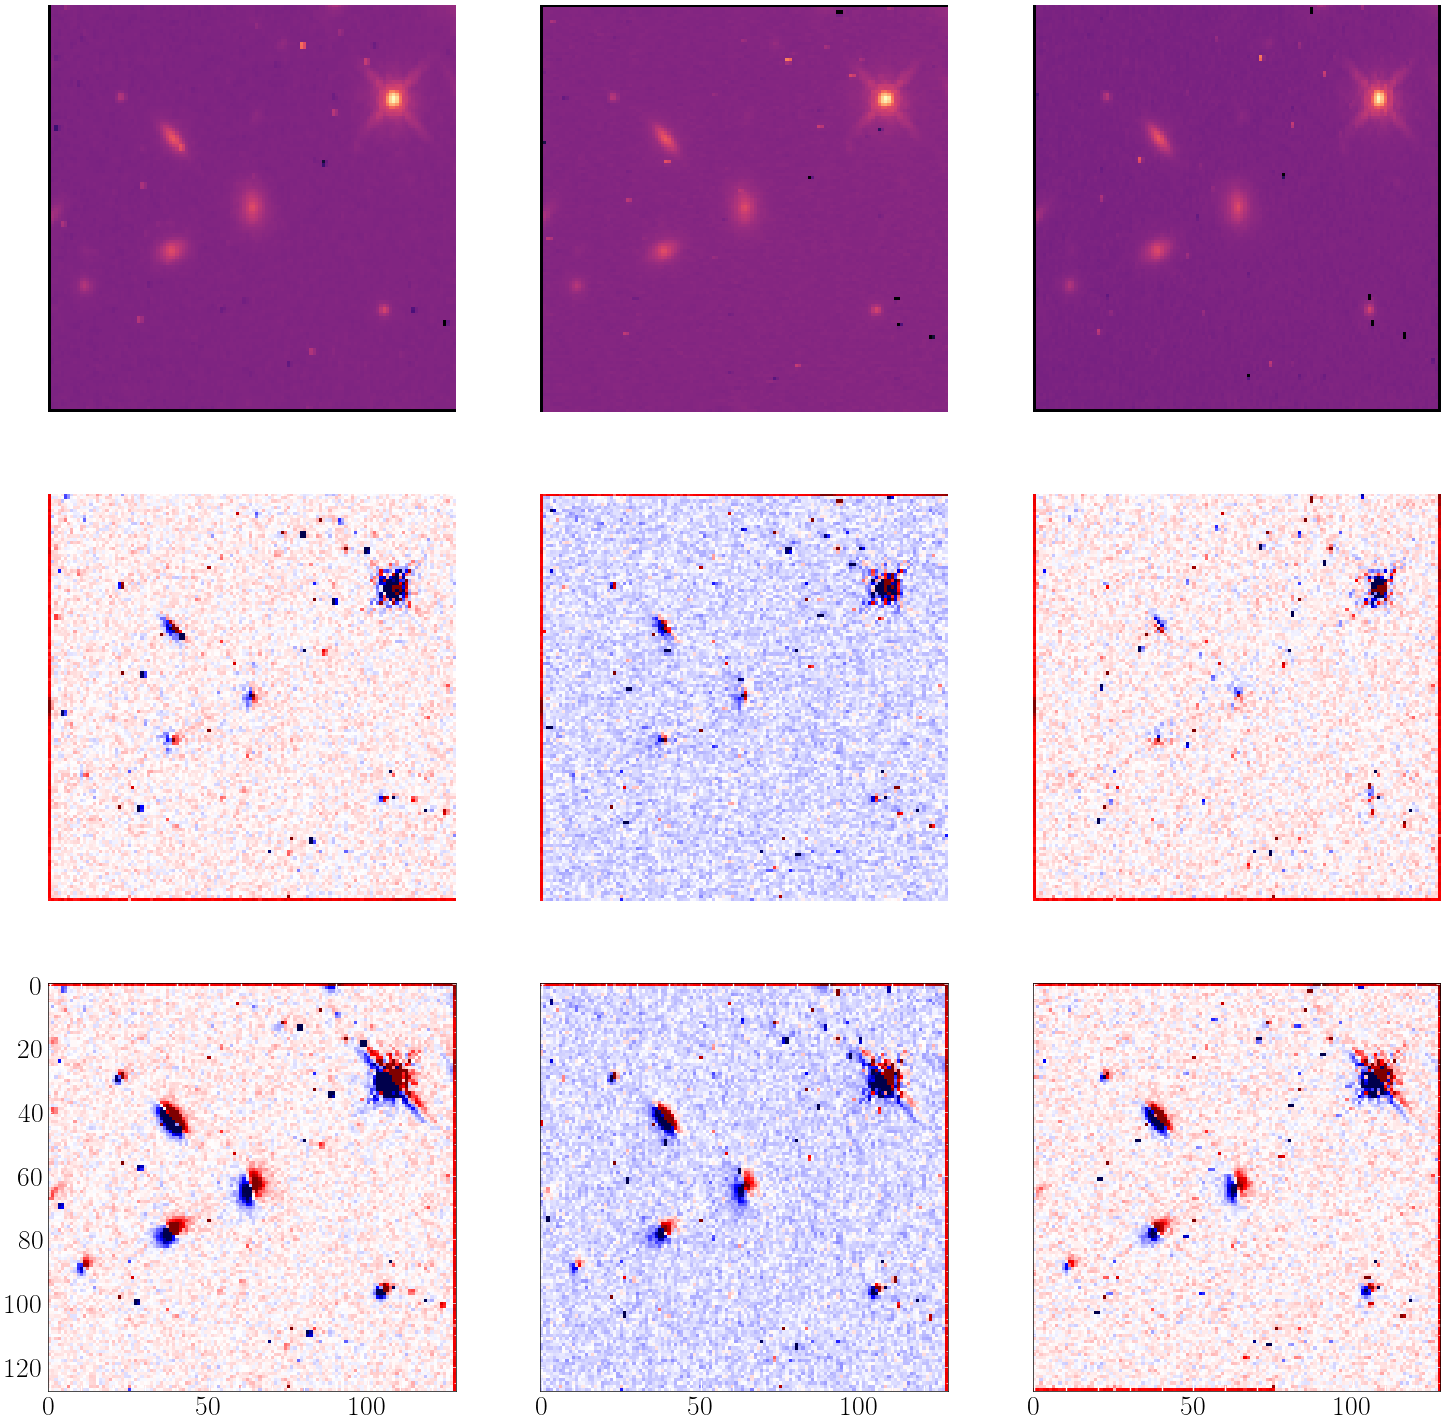

In [108]:
fig, axs = plt.subplots(3, len(wcs_list)-1, figsize=(6 * len(wcs_list)-6, 18), sharey=True)

index = 0
for i in tqdm(range(len(wcs_list))):
    if i == i_ref:
        continue
    ll = chi_sq[i]
    jj = np.unravel_index(np.argmin(ll), (N))
    print(f"Solution for {i} is {y_grid[jj]}")
    y = forward(0, y_grid[jj], 0, i, i_ref)
    y_nothing = forward(0, 0, 0, i, i_ref)
    
    axs[0, index].imshow(y, cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-2, clip=True))
    axs[1, index].imshow(observations[i_ref] - y, cmap="seismic", vmin=-1, vmax=1)
    axs[2, index].imshow(observations[i_ref] - y_nothing, cmap="seismic", vmin=-1, vmax=1)
    index += 1

for i in range(2):
    for j in range(len(wcs_list)-1):
        axs[i, j].axis("off")

# Test to validate that cutouts made from aligned WCS is better

In [450]:
def align_wcs(wcs, shift_x, shift_y, theta):
    hdr = wcs.to_header(True) # True makes it so that we have the SIP coefficients

    pc = wcs.pixel_scale_matrix
    rotation = np.array([[np.cos(theta), -np.sin(theta)],
                         [np.sin(theta), np.cos(theta)]])
    
    new_pc = rotation @ pc
    hdr["PC1_1"] = new_pc[0, 0]
    hdr["PC1_2"] = new_pc[0, 1]
    hdr["PC2_1"] = new_pc[1, 0]
    hdr["PC2_2"] = new_pc[1, 1]
    hdr["CRVAL1"] = hdr["CRVAL1"] + shift_y / 3600 # arcsec to deg
    hdr["CRVAL2"] = hdr["CRVAL2"] + shift_x / 3600
    # make a new wcs based on shift and rotation of the model
    new_wcs = WCS(hdr)
    return new_wcs

In [466]:
TARGET = 2
FILTER = "F160W"


coord0 = SkyCoord("7:23:24.5462", "-73:27:20.172", unit=(u.hourangle, u.deg))
coord1 = SkyCoord("7:23:22.0805", "-73:27:24.575", unit=(u.hourangle, u.deg))
coord2 = SkyCoord("7:23:20.7483", "-73:26:07.203", unit=(u.hourangle, u.deg))
# coord3 = SkyCoord("7:23:01.6118", "-73:26:45.888", unit=(u.hourangle, u.deg))

coords = [coord0, coord1, coord2]
coord = coords[TARGET]

# paths = glob.glob(f"../data/smacs*target{TARGET}*{FILTER.upper()}*.fits")
# data = []
# for p in paths:
#     data.append(fits.open(p))
# observations = np.stack([data[i]["SCI"].data.astype(np.float32) for i in range(len(paths))], axis=0)
# wcs_list = [WCS(data[i]["SCI"].header, data[i]) for i in range(len(paths))]
    
# We need to make larger cutouts to have more context to make alignment faithful 
size = 64 if TARGET == 2 else 128 # TARGET = 2 is close to the edge 
cutouts = {i: [] for i in range(3)}
wcs_lists = {i: [] for i in range(3)}
paths = flt_paths_sorted[FILTER]
for i, path in enumerate(paths):
    data = fits.open(path)
    for target in range(3):
        filename = os.path.split(path)[-1]
        wcs = WCS(data["SCI"].header, data)
        # Very important that the cutouts be made from the active WCS of the file, otherwise the solution changes!!!
        # wcs_solution = np.load(f"../data/smacs_{filename}_target{TARGET}_{FILTER}_iref1_wcs_solutions.npz")
        # wcs = align_wcs(wcs, wcs_solution["x"], wcs_solution["y"], wcs_solution["theta"])
        cutout = Cutout2D(data["SCI", 1].data, coords[target], size, wcs=wcs)
        wcs = cutout.wcs
        cutouts[target].append(cutout.data)
        wcs_lists[target].append(wcs)

observations = np.stack(cutouts[TARGET], axis=0)
wcs_list = wcs_lists[TARGET]

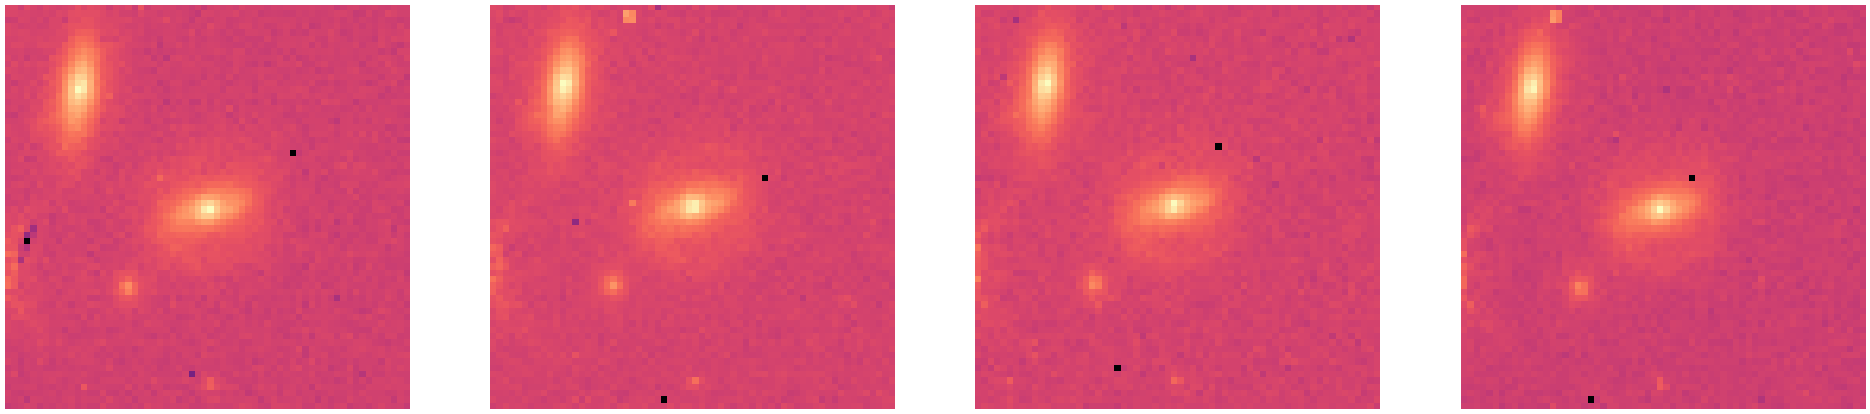

In [467]:
fig, axs = plt.subplots(1, len(wcs_list), figsize=(6*len(wcs_list), 6))
for i in range(len(wcs_list)):
    axs[i].imshow(observations[i], cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-2, clip=True))
    axs[i].axis("off")

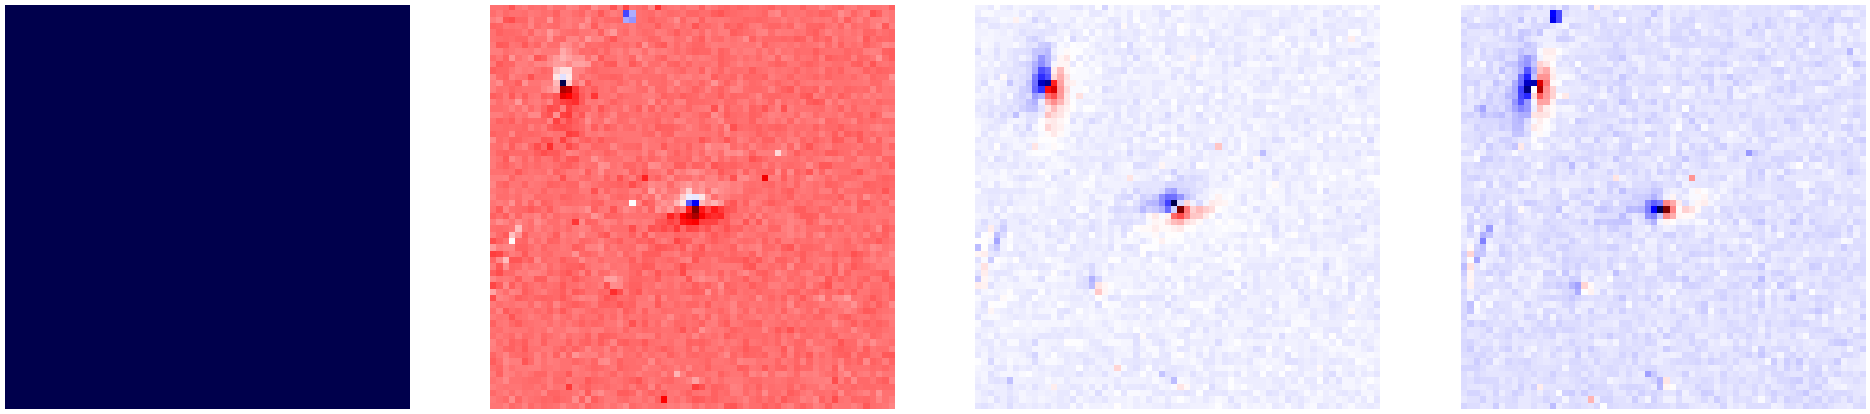

In [468]:
fig, axs = plt.subplots(1, len(wcs_list), figsize=(6*len(wcs_list), 6))
for i in range(len(wcs_list)):
    axs[i].imshow(observations[0] - observations[i], cmap="seismic")
    axs[i].axis("off")

In [469]:
def forward(shift_x, shift_y, theta, i, i_ref):
    # assert i != i_ref
    wcs_ref = wcs_list[i_ref]
    wcs_target = wcs_list[i]
    new_wcs = align_wcs(wcs_target, shift_x, shift_y, theta)
    y_target = observations[i]

    # Construct coordinate grid of reference observation
    u = np.arange(wcs_ref.pixel_shape[0])# + 0.5 Should not add this 0.5 when making coordinates!!
    v = np.arange(wcs_ref.pixel_shape[1])# + 0.5
    u, v = np.meshgrid(u, v, indexing="ij")
    # Then map to reference WCS
    world = wcs_ref.pixel_to_world(u, v)
    # Then map to target pixel grid
    pixel_x, pixel_y = np.stack(new_wcs.world_to_pixel(world), axis=0)
    
    # Finally interpolate data on this coordinate system
    y = interpolate(y_target, pixel_x, pixel_y)
    return y.reshape(*wcs_ref.pixel_shape)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 80.08it/s]


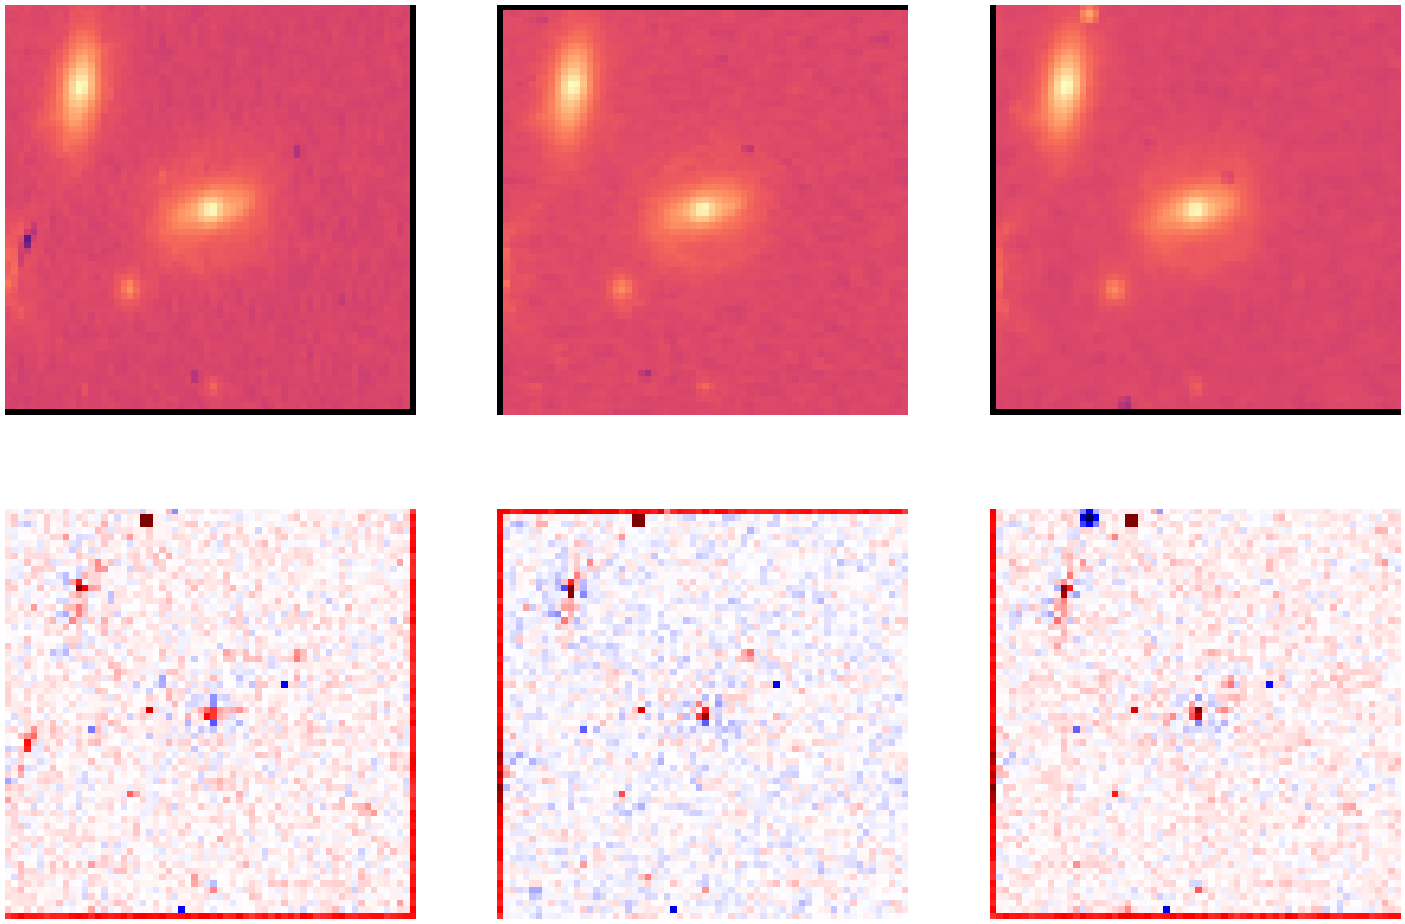

In [473]:
fig, axs = plt.subplots(2, len(wcs_list)-1, figsize=(6 * len(wcs_list)-6, 12), sharey=True)

i_ref = 1
index = 0
for i in tqdm(range(len(wcs_list))):
    if i == i_ref:
        continue
    filename = os.path.split(paths[i])[-1]
    wcs_solution = np.load(f"../data/smacs_{filename}_target{TARGET}_{FILTER}_iref1_wcs_solutions.npz")
    shift_x = wcs_solution["x"]
    shift_y = wcs_solution["y"]
    theta = wcs_solution["theta"]
    y = forward(shift_x, shift_y, theta, i, i_ref)
    axs[0, index].imshow(y, cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-2, clip=True))
    axs[1, index].imshow(observations[i_ref] - y, cmap="seismic", vmin=-1, vmax=1)
    index += 1
        
for i in range(2):
    for j in range(len(wcs_list)-1):
        axs[i, j].axis("off")